# Fast parity-first multi-kernel SVC

The notebook first proves parity with the old Raw and 52-feature Current Best pipelines. Only then does it tune standalone block scales and compare additive/generalized-product kernels.


## 1. Data


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
from svc_multikernel_experiments import *

SEED = 0xFACED
DATA_DIR = Path('./data') if not Path('/kaggle/input').exists() else Path('/kaggle/input/competitions/week-03-hidden-pairs')
train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df = pd.read_csv(DATA_DIR / 'validation.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')
features = [c for c in train_df if c not in {'row_id', 'target'}]
assert len(features) == 512 and 'row_id' not in features
assert features == [c for c in val_df if c not in {'row_id', 'target'}] == [c for c in test_df if c != 'row_id']
X_train = train_df[features].to_numpy()
y_train = train_df.target.to_numpy()
print('train:', X_train.shape, '| validation is loaded for schema only and is not evaluated')


train: (2520, 512) | validation is loaded for schema only and is not evaluated


## 2. QUICK/FULL configuration


In [2]:
QUICK_MODE = True
FULL_CONFIRMATION_MODE = False  # clean-stage: historical full confirmation paused
N_SPLITS = 5
CV_SEEDS = [SEED] if QUICK_MODE else [SEED + i for i in range(5)]

CACHE_DIR = Path('.svc_multikernel_cache_v2')
REBUILD_CACHE = False
CACHE_N_JOBS = 1       # feature building is memory-heavy
SVC_N_JOBS = -1        # folds/C values use the cached distances
COORD_N_BINS = 8
COORD_ALPHA = 5.0
PCA_COMPONENTS = 128

RAW_REFERENCE = {'C': 3.447606, 'gamma': 0.003110}
CURRENT_BEST_CONFIG = 'coord_monotonic'
CURRENT_BEST_PARAMS = {
    'kernel_type': 'product',
    'C': 18.152351,
    'gamma_raw': 0.002496,
    'gamma_geom': 0.010154,
}

GAMMA_MULTIPLIERS = [0.5, 1.0, 2.0]
RAW_MULTIKERNEL_GAMMA = CURRENT_BEST_PARAMS['gamma_raw']
C_GRID = [3.0, 10.0, 18.0, 30.0]
FAST_C_GRID = [6.0, 18.0, 30.0]
ACTIVE_C_GRID = FAST_C_GRID if QUICK_MODE else C_GRID
COMPOSITE_C_GRID = [6.0, 18.0, 30.0]

FINE6_WEIGHTS = {
    'raw': 0.68, 'geometry': 0.10, 'aggregates': 0.05,
    'density': 0.10, 'knn': 0.05, 'coord': 0.02, 'pca128': 0.00,
}
BEST_PREVIOUS_ADDITIVE_CONFIG = 'fine_no_coord'

PARITY_TOLERANCE = 0.002
RAW_MIN_EXPECTED_AUC = 0.925
CONFIRM_CONFIGS = [
    'fine_no_coord', 'fine_6', 'fine_5', 'add_geom12_density10'
]
COMPOSITE_CONFIRM_CONFIGS = [
    'cb30_no_coord70', 'cb35_fine65'
]
RUN_EXTERNAL_VALIDATION = False  # clean-stage: legacy validation paused
VALIDATION_CONFIGS = ['fine_6',
    'cb35_fine65',]
CREATE_SUBMISSION = False
FINAL_OPTUNA_TRIALS = 50
FINAL_OPTUNA_SEEDS = [SEED + i for i in range(5)]  # repeated 5x5 CV, cache is reused
FINAL_C_BOUNDS = (2.0, 50.0)
FINAL_TEMPERATURE_BOUNDS = (0.5, 2.0)
FINAL_SUBMISSION_PATH = Path('submission_fine6_optuna.csv')

RUN_BLEND_VALIDATION = False  # clean-stage: legacy blend validation paused
BLEND_VALIDATION_CONFIGS = [
    'f78_pca_agg75',  # 22% aux — лучший CV mean
    'f82_pca_agg75',  # 18% aux — лучший компромисс
    'f86_pca_agg75',  # 14% aux — консервативный вариант
]
CREATE_BLEND_SUBMISSION = False  # clean-stage: no submission yet


## Clean Multi-Kernel v1 — staged 25-fold search

Uses only the already-existing 5×5 legacy folds and clean sidecar distance matrices. No split, feature building, distance-cache building, validation, test prediction, Optuna, or submission is allowed here.


In [3]:
# Reload the edited helper even when this notebook kernel was already open.
import importlib
import svc_multikernel_experiments as _svc_multikernel_experiments
importlib.reload(_svc_multikernel_experiments)
from svc_multikernel_experiments import *

# Existing seed bank and existing caches only.
CLEAN_EXISTING_SEEDS = tuple(FINAL_OPTUNA_SEEDS)
CLEAN_DERIVED_CACHE_DIR = Path('.svc_clean_derived_cache_v1')

CLEAN_V1_BLOCKS = (
    'raw',
    'geometry',
    'density',
    'aggregates_white4',
    'knn',
)
BEST_KNN_GAMMA_FROM_PREVIOUS_SCREEN = 0.023407610601125856
CLEAN_FIXED_GAMMAS = {
    'raw': 0.002496,
    'geometry': 0.001587,
    'density': 0.002991,
    'aggregates_white4': 0.018420,
    'knn': BEST_KNN_GAMMA_FROM_PREVIOUS_SCREEN,
}
CLEAN_REFERENCE_GAMMAS = {
    **CLEAN_FIXED_GAMMAS,
    'coord_white4': 0.025934,
}
CLEAN_V1_C_GRID = [0.5, 1.0, 2.0, 3.0, 6.0, 10.0]
GEOMETRY_WEIGHTS = [0.10, 0.15, 0.20, 0.25, 0.30]
DENSITY_WEIGHTS = [0.05, 0.10, 0.15, 0.20, 0.25]
AGG_WEIGHTS = [0.00, 0.03, 0.05, 0.08]
KNN_WEIGHTS = [0.00, 0.03, 0.06]

# Manifest-only loaders: missing folds/files cause an error, never a rebuild.
clean_base_cache = load_existing_distance_cache(
    y_train,
    seeds=CLEAN_EXISTING_SEEDS,
    cache_dir=CACHE_DIR,
    n_splits=N_SPLITS,
    n_bins=COORD_N_BINS,
    alpha=COORD_ALPHA,
    pca_components=PCA_COMPONENTS,
)
clean_derived_cache = load_existing_clean_derived_cache(
    clean_base_cache,
    cache_dir=CLEAN_DERIVED_CACHE_DIR,
)

assert clean_base_cache.cache_builds == 0
assert clean_derived_cache.cache_builds == 0
assert len(clean_base_cache.folds) == len(clean_derived_cache.folds) == 25
clean_cache_uses_exact_legacy_fold_keys = all(
    base.repeat == derived.repeat
    and base.fold == derived.fold
    and base.seed == derived.seed
    and base.cache_key == derived.base_cache_key
    and np.array_equal(base.train_idx, derived.train_idx)
    and np.array_equal(base.valid_idx, derived.valid_idx)
    for base, derived in zip(clean_base_cache.folds, clean_derived_cache.folds)
)
assert clean_cache_uses_exact_legacy_fold_keys

print('existing legacy folds reused:', len(clean_base_cache.folds))
print('existing clean sidecar folds reused:', clean_derived_cache.cache_hits)
print('new folds/features/distances built: 0')


existing legacy folds reused: 25
existing clean sidecar folds reused: 25
new folds/features/distances built: 0


### Frozen pair-screening conclusions and baselines


In [4]:
# Frozen evidence from the completed pair screen; nothing is retuned here.
clean_pair_screening_conclusions = pd.DataFrame([
    {'block': 'geometry', 'status': 'useful', 'best_pair_weight': 0.20,
     'pair_CV': 0.930708, 'delta_vs_raw': 0.001517},
    {'block': 'density', 'status': 'useful', 'best_pair_weight': 0.20,
     'pair_CV': 0.930545, 'delta_vs_raw': 0.001355},
    {'block': 'aggregates_white4', 'status': 'mildly useful', 'best_pair_weight': 0.20,
     'pair_CV': 0.929928, 'delta_vs_raw': 0.000738},
    {'block': 'knn', 'status': 'mildly useful', 'best_pair_weight': 0.06,
     'pair_CV': 0.929776, 'delta_vs_raw': 0.000585},
    {'block': 'coord_white4', 'status': 'not useful with raw', 'best_pair_weight': 0.20,
     'pair_CV': 0.929206, 'delta_vs_raw': 0.000015},
])
display(clean_pair_screening_conclusions)
print('Frozen KNN gamma:', BEST_KNN_GAMMA_FROM_PREVIOUS_SCREEN)

# Frozen historical Fine6: same existing 25 folds, no tuning.
LEGACY_FINE6_C = 6.0
LEGACY_FINE6_GAMMAS = {
    'raw': 0.002496,
    'geometry': 0.012772,
    'aggregates': 0.073837,
    'density': 0.023941,
    'knn': 0.187890,
    'coord': 0.055470,
    'pca128': 0.001384,
}
LEGACY_FINE6_CONFIG = {
    'mode': 'additive',
    'weights': dict(FINE6_WEIGHTS),
}
clean_fine6_run = evaluate_config_grid(
    clean_base_cache,
    LEGACY_FINE6_CONFIG,
    LEGACY_FINE6_GAMMAS,
    [LEGACY_FINE6_C],
    SVC_N_JOBS,
)


,block,status,best_pair_weight,pair_CV,delta_vs_raw
0,geometry,useful,0.20,0.930708,0.001517
1,density,useful,0.20,0.930545,0.001355
2,aggregates_white4,mildly useful,0.20,0.929928,0.000738
3,knn,mildly useful,0.06,0.929776,0.000585
4,coord_white4,not useful with raw,0.20,0.929206,0.000015


Frozen KNN gamma: 0.023407610601125856


## Engineered feature redundancy audit

Train-only unsupervised diagnostics. Supervised engineered train features use the same inner-OOF builders as the modeling pipeline; validation and test data are not used. Nothing is pruned or fed back into model configuration.


In [11]:
from scipy.stats import rankdata
import matplotlib.pyplot as plt

TOP_CORRELATED_PAIRS = 15
CORRELATION_CLUSTER_THRESHOLD = 0.95
SHOW_REDUNDANCY_HEATMAPS = True
AUDIT_BLOCK_ORDER = (
    'geometry', 'density', 'aggregates', 'knn',
    'coord', 'old_aux', 'pca128',
)

# Exactly one train-only feature build. y_train is used only inside the existing
# leakage-safe inner-OOF feature builders and is not used by any audit statistic.
audit_blocks, audit_feature_names = build_feature_audit_blocks(
    X_train, y_train,
    builder_seed=SEED + INNER_SEED_OFFSET,
    n_bins=COORD_N_BINS,
    alpha=COORD_ALPHA,
    pca_components=PCA_COMPONENTS,
)


In [12]:
def audit_correlation_matrices(block):
    block = np.asarray(block, dtype=float)
    n_features = block.shape[1]
    std = block.std(axis=0, ddof=0)
    active = std >= 1e-8
    pearson = np.full((n_features, n_features), np.nan, dtype=float)
    spearman = np.full((n_features, n_features), np.nan, dtype=float)
    if active.sum() == 1:
        index = np.flatnonzero(active)[0]
        pearson[index, index] = spearman[index, index] = 1.0
    elif active.sum() >= 2:
        active_values = block[:, active]
        ranked_values = rankdata(active_values, axis=0, method='average')
        pearson[np.ix_(active, active)] = np.corrcoef(active_values, rowvar=False)
        spearman[np.ix_(active, active)] = np.corrcoef(ranked_values, rowvar=False)
    return pearson, spearman, std


def audit_pair_table(names, pearson, spearman):
    rows = []
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            p, s = pearson[i, j], spearman[i, j]
            if not (np.isfinite(p) and np.isfinite(s)):
                continue
            rows.append({
                'feature_1': names[i], 'feature_2': names[j],
                'pearson': p, 'spearman': s,
                'abs_pearson': abs(p), 'abs_spearman': abs(s),
                '_sort': max(abs(p), abs(s)),
            })
    columns = ['feature_1', 'feature_2', 'pearson', 'spearman',
               'abs_pearson', 'abs_spearman', '_sort']
    return pd.DataFrame(rows, columns=columns).sort_values(
        '_sort', ascending=False).reset_index(drop=True)


def audit_effective_rank(block):
    covariance = np.atleast_2d(np.cov(block, rowvar=False, ddof=1))
    eigvals = np.clip(np.linalg.eigvalsh(covariance), 0.0, None)
    eigvals = np.sort(eigvals)[::-1]
    total = eigvals.sum()
    if total <= 0:
        return 0.0, 0.0, 0.0, 0.0, 0.0
    probabilities = eigvals / total
    positive = probabilities > 0
    rank_pr = total ** 2 / np.square(eigvals).sum()
    rank_entropy = np.exp(-np.sum(
        probabilities[positive] * np.log(probabilities[positive])))
    top = lambda k: eigvals[:min(k, len(eigvals))].sum() / total
    return rank_pr, rank_entropy, top(1), top(3), top(5)


def audit_summary_row(name, block, pair_table):
    pearson_values = pair_table['abs_pearson'].to_numpy()
    spearman_values = pair_table['abs_spearman'].to_numpy()
    rank_pr, rank_entropy, top1, top3, top5 = audit_effective_rank(block)

    def stats(values, prefix):
        if len(values) == 0:
            return {
                f'max_abs_{prefix}': np.nan,
                f'median_abs_{prefix}': np.nan,
                f'p90_abs_{prefix}': np.nan,
                f'p95_abs_{prefix}': np.nan,
                f'pairs_{prefix}_gt_090': 0,
                f'pairs_{prefix}_gt_095': 0,
                f'pairs_{prefix}_gt_098': 0,
                f'fraction_{prefix}_gt_095': 0.0,
            }
        return {
            f'max_abs_{prefix}': values.max(),
            f'median_abs_{prefix}': np.median(values),
            f'p90_abs_{prefix}': np.quantile(values, 0.90),
            f'p95_abs_{prefix}': np.quantile(values, 0.95),
            f'pairs_{prefix}_gt_090': int((values > 0.90).sum()),
            f'pairs_{prefix}_gt_095': int((values > 0.95).sum()),
            f'pairs_{prefix}_gt_098': int((values > 0.98).sum()),
            f'fraction_{prefix}_gt_095': float((values > 0.95).mean()),
        }

    n_features = block.shape[1]
    return {
        'block': name,
        'n_features': n_features,
        **stats(pearson_values, 'pearson'),
        **stats(spearman_values, 'spearman'),
        'effective_rank_pr': rank_pr,
        'effective_rank_entropy': rank_entropy,
        'effective_rank_pr_fraction': rank_pr / n_features,
        'effective_rank_entropy_fraction': rank_entropy / n_features,
        'top1_variance_fraction': top1,
        'top3_variance_fraction': top3,
        'top5_variance_fraction': top5,
    }


def audit_correlation_groups(block_name, names, pearson, spearman, threshold):
    parent = list(range(len(names)))

    def find(index):
        while parent[index] != index:
            parent[index] = parent[parent[index]]
            index = parent[index]
        return index

    def union(left, right):
        left, right = find(left), find(right)
        if left != right:
            parent[right] = left

    combined = np.fmax(np.abs(pearson), np.abs(spearman))
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            if np.isfinite(combined[i, j]) and combined[i, j] >= threshold:
                union(i, j)
    groups = {}
    for index, feature in enumerate(names):
        groups.setdefault(find(index), []).append(feature)
    rows = []
    group_id = 1
    for features_in_group in sorted(groups.values(), key=lambda x: (-len(x), x)):
        if len(features_in_group) < 2:
            continue
        rows.append({
            'block': block_name,
            'group_id': group_id,
            'size': len(features_in_group),
            'features': ', '.join(features_in_group),
        })
        group_id += 1
    return rows


def audit_feature_scores(block_name, names, pearson, spearman):
    abs_p, abs_s = np.abs(pearson), np.abs(spearman)
    combined = np.fmax(abs_p, abs_s)
    rows = []
    for index, feature in enumerate(names):
        valid_p = np.delete(abs_p[index], index)
        valid_s = np.delete(abs_s[index], index)
        valid_c = np.delete(combined[index], index)
        valid_p, valid_s = valid_p[np.isfinite(valid_p)], valid_s[np.isfinite(valid_s)]
        valid_c = valid_c[np.isfinite(valid_c)]
        max_p = valid_p.max() if len(valid_p) else np.nan
        max_s = valid_s.max() if len(valid_s) else np.nan
        top3 = np.sort(valid_c)[-3:] if len(valid_c) else np.array([np.nan])
        rows.append({
            'block': block_name,
            'feature': feature,
            'max_abs_pearson_with_other': max_p,
            'max_abs_spearman_with_other': max_s,
            'mean_top3_abs_corr': np.nanmean(top3),
            'redundancy_score': np.nanmax([max_p, max_s]),
        })
    return rows


In [13]:
audit_correlation_matrices_by_block = {}
feature_pair_tables = {}
audit_summary_rows = []
audit_cluster_rows = []
audit_score_rows = []
audit_constant_features = {}

for audit_block_name in AUDIT_BLOCK_ORDER:
    audit_block = np.asarray(audit_blocks[audit_block_name], dtype=float)
    audit_names = audit_feature_names[audit_block_name]
    assert np.isfinite(audit_block).all()
    assert len(audit_names) == audit_block.shape[1]

    audit_means = audit_block.mean(axis=0)
    audit_stds = audit_block.std(axis=0, ddof=0)
    audit_nonconstant = audit_stds >= 1e-8
    audit_constant_features[audit_block_name] = [
        audit_names[i] for i in np.flatnonzero(~audit_nonconstant)]
    if audit_nonconstant.any():
        assert np.allclose(audit_means[audit_nonconstant], 0.0, atol=1e-6)
        assert np.allclose(audit_stds[audit_nonconstant], 1.0, atol=1e-5)

    audit_pearson, audit_spearman, _ = audit_correlation_matrices(audit_block)
    audit_correlation_matrices_by_block[audit_block_name] = {
        'pearson': audit_pearson,
        'spearman': audit_spearman,
    }
    audit_pairs = audit_pair_table(audit_names, audit_pearson, audit_spearman)
    feature_pair_tables[audit_block_name] = audit_pairs.drop(columns='_sort').head(
        TOP_CORRELATED_PAIRS).copy()
    audit_summary_rows.append(
        audit_summary_row(audit_block_name, audit_block, audit_pairs))
    audit_cluster_rows.extend(audit_correlation_groups(
        audit_block_name, audit_names, audit_pearson, audit_spearman,
        CORRELATION_CLUSTER_THRESHOLD))
    audit_score_rows.extend(audit_feature_scores(
        audit_block_name, audit_names, audit_pearson, audit_spearman))

feature_redundancy_summary = pd.DataFrame(audit_summary_rows).sort_values(
    'effective_rank_pr_fraction', ascending=True).reset_index(drop=True)
feature_correlation_clusters = pd.DataFrame(
    audit_cluster_rows, columns=['block', 'group_id', 'size', 'features'])
feature_redundancy_scores = pd.DataFrame(audit_score_rows).sort_values(
    ['block', 'redundancy_score'], ascending=[True, False]).reset_index(drop=True)

display(feature_redundancy_summary)
print('Constant / near-constant features (std < 1e-8):')
display(pd.DataFrame([
    {'block': block, 'n_constant': len(names), 'features': ', '.join(names)}
    for block, names in audit_constant_features.items()
]))

print(f'Top {TOP_CORRELATED_PAIRS} correlated pairs per block:')
for audit_block_name in AUDIT_BLOCK_ORDER:
    print(f'[{audit_block_name}]')
    display(feature_pair_tables[audit_block_name])

print(f'Near-duplicate groups at correlation >= {CORRELATION_CLUSTER_THRESHOLD:.2f}:')
display(feature_correlation_clusters)

audit_score_blocks = {'geometry', 'density', 'aggregates', 'coord', 'old_aux'}
audit_top_redundant_features = (
    feature_redundancy_scores[
        feature_redundancy_scores['block'].isin(audit_score_blocks)]
    .groupby('block', sort=False, group_keys=False).head(20)
    .reset_index(drop=True)
)
print('Top-20 most redundant features per requested block:')
display(audit_top_redundant_features)


,block,n_features,max_abs_pearson,median_abs_pearson,p90_abs_pearson,p95_abs_pearson,pairs_pearson_gt_090,pairs_pearson_gt_095,pairs_pearson_gt_098,fraction_pearson_gt_095,...,pairs_spearman_gt_095,pairs_spearman_gt_098,fraction_spearman_gt_095,effective_rank_pr,effective_rank_entropy,effective_rank_pr_fraction,effective_rank_entropy_fraction,top1_variance_fraction,top3_variance_fraction,top5_variance_fraction
0,old_aux,52,1.000000,0.755807,0.958220,0.984495,319,164,75,0.123680,...,159,99,0.119910,1.658591,2.664134,0.031896,0.051233,0.768274,0.906503,0.958095
1,geometry,32,1.000000,0.718599,0.968142,0.990992,129,76,43,0.153226,...,97,69,0.195565,1.706071,2.428260,0.053315,0.075883,0.749710,0.938629,0.987039
2,density,14,0.998753,0.969807,0.994531,0.997641,73,53,27,0.582418,...,53,30,0.582418,1.163587,1.374808,0.083113,0.098201,0.925013,0.995835,0.998735
3,coord,10,0.999957,0.954764,0.994997,0.999904,45,25,13,0.555556,...,13,5,0.288889,1.080550,1.222711,0.108055,0.122271,0.961702,0.993805,0.999971
4,aggregates,6,0.998081,0.718345,0.909327,0.936687,3,1,1,0.066667,...,1,1,0.066667,1.599851,2.116112,0.266642,0.352685,0.776123,0.973416,0.999817
5,knn,2,0.628212,0.628212,0.628212,0.628212,0,0,0,0.000000,...,0,0,0.000000,1.434051,1.616420,0.717026,0.808210,0.814106,1.000000,1.000000
6,pca128,128,0.004203,0.000099,0.000760,0.001092,0,0,0,0.000000,...,0,0,0.000000,127.996150,127.998082,0.999970,0.999985,0.007990,0.023918,0.039802


Constant / near-constant features (std < 1e-8):


,block,n_constant,features
0,geometry,0,
1,density,0,
2,aggregates,0,
3,knn,0,
4,coord,0,
5,old_aux,0,
6,pca128,0,


Top 15 correlated pairs per block:
[geometry]


,feature_1,feature_2,pearson,spearman,abs_pearson,abs_spearman
0,d_mahal_0,mahal_sq_0,0.988011,1.000000,0.988011,1.000000
1,mahal_norm_diff,mahal_log_ratio,0.997195,1.000000,0.997195,1.000000
2,mahal_sq_diff,rda_diff_1p0,1.000000,1.000000,1.000000,1.000000
3,mahal_norm_diff,rda_norm_diff_1p0,1.000000,1.000000,1.000000,1.000000
4,mahal_log_ratio,rda_norm_diff_1p0,0.997195,1.000000,0.997195,1.000000
5,d_mahal_1,mahal_sq_1,0.975217,1.000000,0.975217,1.000000
6,mid_cos,mid_axis_snr,0.863467,1.000000,0.863467,1.000000
7,fisher_cos,fisher_axis_snr,0.996210,1.000000,0.996210,1.000000
8,rda_diff_0p0,fisher_axis,0.999959,0.999977,0.999959,0.999977
9,d_euclid_diff,mid_cos,0.999757,0.999796,0.999757,0.999796


...

,feature_1,feature_2,pearson,spearman,abs_pearson,abs_spearman
0,pc_2,pc_5,2.317777e-10,-0.136795,2.317777e-10,0.136795
1,pc_1,pc_3,3.353126e-12,-0.122248,3.353126e-12,0.122248
2,pc_3,pc_5,6.469634e-10,0.116714,6.469634e-10,0.116714
3,pc_0,pc_1,-1.062241e-14,-0.111692,1.062241e-14,0.111692
4,pc_10,pc_11,-7.447102e-08,-0.104067,7.447102e-08,0.104067
5,pc_1,pc_5,3.123446e-10,-0.081694,3.123446e-10,0.081694
6,pc_15,pc_19,-1.625861e-06,-0.080649,1.625861e-06,0.080649
7,pc_8,pc_11,2.626982e-07,-0.071949,2.626982e-07,0.071949
8,pc_1,pc_10,2.017566e-09,0.065301,2.017566e-09,0.065301
9,pc_10,pc_39,-7.976950e-06,-0.063090,7.976950e-06,0.063090


Near-duplicate groups at correlation >= 0.95:


,block,group_id,size,features
0,geometry,1,18,"d_euclid_diff, proj_w, d_mahal_0, d_mahal_1, d..."
1,geometry,2,13,"lda_score, mahal_norm_diff, mahal_log_ratio, r..."
2,density,1,13,"qda_score, ppca_logp0_16, ppca_logp1_16, ppca_..."
3,aggregates,1,2,"total, log1p_sum"
4,coord,1,10,"coord_0, coord_1, coord_2, coord_3, coord_4, c..."
5,old_aux,1,32,"d_euclid_diff, proj_w, d_mahal_0, d_mahal_1, d..."
6,old_aux,2,13,"lda_score, mahal_norm_diff, mahal_log_ratio, r..."


Top-20 most redundant features per requested block:


,block,feature,max_abs_pearson_with_other,max_abs_spearman_with_other,mean_top3_abs_corr,redundancy_score
0,aggregates,total,0.998081,0.999242,0.897630,0.999242
1,aggregates,log1p_sum,0.998081,0.999242,0.904022,0.999242
2,aggregates,max,0.910376,0.834538,0.805086,0.910376
3,aggregates,relative_std,0.840452,0.805308,0.809598,0.840452
4,aggregates,max_share,0.840452,0.805308,0.755471,0.840452
...,...,...,...,...,...,...
65,old_aux,coord_0,0.999957,0.999931,0.994632,0.999957
66,old_aux,coord_1,0.999957,0.999931,0.994846,0.999957
67,old_aux,coord_2,0.999913,0.999901,0.969701,0.999913
68,old_aux,coord_3,0.999913,0.999901,0.969846,0.999913


In [14]:
def audit_geometry_family(name):
    if name.startswith('fisher_'):
        return 'fisher'
    if name.startswith('rda_'):
        return 'rda'
    if name.startswith(('mahal_', 'd_mahal_')):
        return 'mahalanobis'
    if name.startswith('mid_'):
        return 'midpoint'
    if name in {'d_euclid_diff', 'proj_w', 'cos_w', 'lda_score'}:
        return 'base_geometry'
    return 'other'


def audit_density_family(name):
    if name.startswith('ppca_'):
        return 'ppca'
    if name == 'qda_score':
        return 'qda'
    if name == 'pca_subspace_diff':
        return 'pca_subspace'
    return 'other'


def audit_family_rows(block_name, family_function):
    names = audit_feature_names[block_name]
    families = [family_function(name) for name in names]
    corr = audit_correlation_matrices_by_block[block_name]
    grouped = {}
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            p, s = corr['pearson'][i, j], corr['spearman'][i, j]
            if not (np.isfinite(p) and np.isfinite(s)):
                continue
            key = tuple(sorted((families[i], families[j])))
            grouped.setdefault(key, []).append((abs(p), abs(s)))
    rows = []
    for (family_1, family_2), values in sorted(grouped.items()):
        values = np.asarray(values)
        rows.append({
            'block': block_name,
            'family_1': family_1,
            'family_2': family_2,
            'n_pairs': len(values),
            'mean_abs_pearson': values[:, 0].mean(),
            'max_abs_pearson': values[:, 0].max(),
            'mean_abs_spearman': values[:, 1].mean(),
            'max_abs_spearman': values[:, 1].max(),
        })
    return rows, pd.DataFrame({'feature': names, 'family': families})


audit_geometry_family_rows, audit_geometry_family_map = audit_family_rows(
    'geometry', audit_geometry_family)
audit_density_family_rows, audit_density_family_map = audit_family_rows(
    'density', audit_density_family)
feature_family_summary = pd.DataFrame(
    audit_geometry_family_rows + audit_density_family_rows
).sort_values(['block', 'max_abs_spearman'], ascending=[True, False]).reset_index(drop=True)

print('Geometry family coverage (including any unmatched names as other):')
display(audit_geometry_family_map.groupby('family', as_index=False).agg(
    n_features=('feature', 'size'), features=('feature', lambda x: ', '.join(x))))
print('Density family coverage (including any unmatched names as other):')
display(audit_density_family_map.groupby('family', as_index=False).agg(
    n_features=('feature', 'size'), features=('feature', lambda x: ', '.join(x))))
print('Family-level correlation summary:')
display(feature_family_summary)


Geometry family coverage (including any unmatched names as other):


,family,n_features,features
0,base_geometry,4,"d_euclid_diff, proj_w, cos_w, lda_score"
1,fisher,4,"fisher_axis, fisher_orth, fisher_cos, fisher_a..."
2,mahalanobis,8,"d_mahal_0, d_mahal_1, d_mahal_diff, mahal_sq_0..."
3,midpoint,4,"mid_axis, mid_orth, mid_cos, mid_axis_snr"
4,rda,12,"rda_diff_0p0, rda_norm_diff_0p0, rda_diff_0p1,..."


Density family coverage (including any unmatched names as other):


,family,n_features,features
0,pca_subspace,1,pca_subspace_diff
1,ppca,12,"ppca_logp0_16, ppca_logp1_16, ppca_llr_16, ppc..."
2,qda,1,qda_score


Family-level correlation summary:


,block,family_1,family_2,n_pairs,mean_abs_pearson,max_abs_pearson,mean_abs_spearman,max_abs_spearman
0,density,ppca,ppca,66,0.965753,0.998753,0.970768,0.998664
1,density,ppca,qda,12,0.895173,0.973330,0.909184,0.975557
2,density,pca_subspace,qda,1,0.810358,0.810358,0.808973,0.808973
3,density,pca_subspace,ppca,12,0.656851,0.773044,0.657816,0.756847
4,geometry,fisher,fisher,6,0.772353,0.996210,0.820985,1.000000
5,geometry,mahalanobis,mahalanobis,28,0.813331,0.997195,0.846486,1.000000
6,geometry,mahalanobis,rda,96,0.737132,1.000000,0.800899,1.000000
7,geometry,midpoint,midpoint,6,0.922803,0.989386,0.965880,1.000000
8,geometry,fisher,rda,48,0.719508,0.999959,0.737276,0.999977
9,geometry,base_geometry,midpoint,16,0.832855,0.999757,0.839817,0.999796


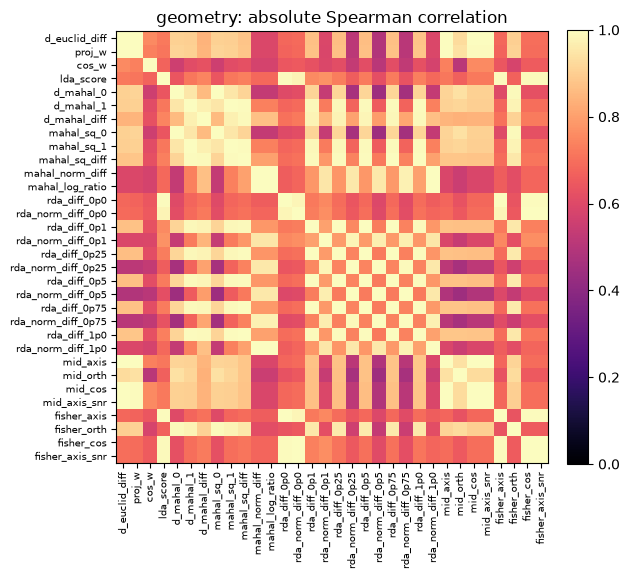

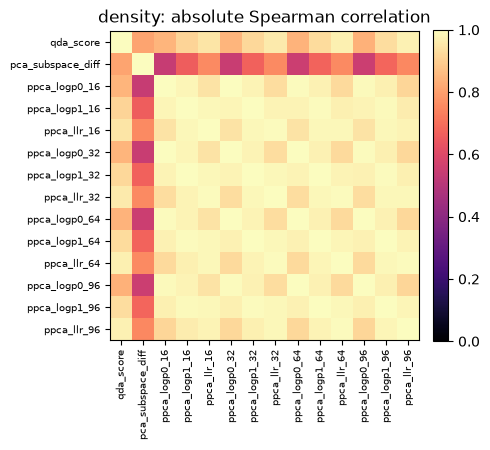

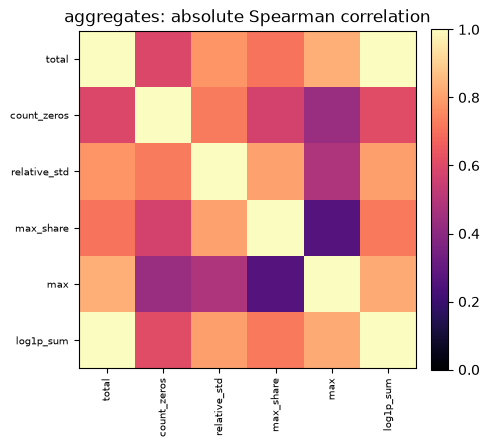

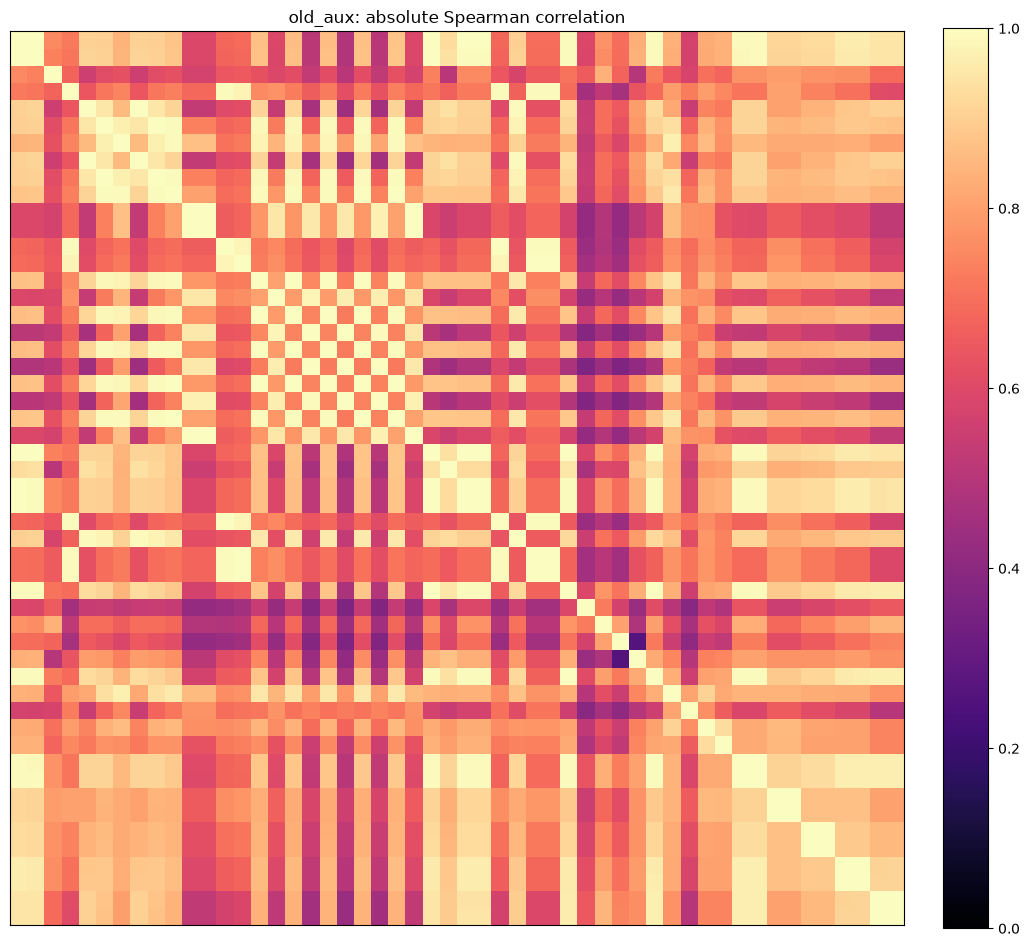

PCA128 control looks well-conditioned by Pearson correlation: max off-diagonal |r|=0.0042

Most redundant blocks:
1. old_aux: 52 features, effective rank = 1.66 (3.2%)
2. geometry: 32 features, effective rank = 1.71 (5.3%)
3. density: 14 features, effective rank = 1.16 (8.3%)
4. coord: 10 features, effective rank = 1.08 (10.8%)
5. aggregates: 6 features, effective rank = 1.60 (26.7%)
6. knn: 2 features, effective rank = 1.43 (71.7%)
7. pca128: 128 features, effective rank = 128.00 (100.0%)

Highly correlated pairs (absolute Spearman > 0.95):
old_aux: 159 pairs
geometry: 97 pairs
density: 53 pairs
coord: 13 pairs
aggregates: 1 pairs
knn: 0 pairs
pca128: 0 pairs


In [15]:
if SHOW_REDUNDANCY_HEATMAPS:
    for audit_block_name in ('geometry', 'density', 'aggregates', 'old_aux'):
        audit_matrix = np.abs(
            audit_correlation_matrices_by_block[audit_block_name]['spearman'])
        audit_matrix = np.nan_to_num(audit_matrix, nan=0.0)
        audit_names = audit_feature_names[audit_block_name]
        audit_size = min(11.0, max(5.0, 0.20 * len(audit_names)))
        fig, ax = plt.subplots(figsize=(audit_size, audit_size))
        image = ax.imshow(audit_matrix, vmin=0.0, vmax=1.0, cmap='magma')
        ax.set_title(f'{audit_block_name}: absolute Spearman correlation')
        if len(audit_names) <= 40:
            ax.set_xticks(range(len(audit_names)), audit_names, rotation=90, fontsize=7)
            ax.set_yticks(range(len(audit_names)), audit_names, fontsize=7)
        else:
            ax.set_xticks([])
            ax.set_yticks([])
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
        fig.tight_layout()
        plt.show()

audit_pca_row = feature_redundancy_summary.loc[
    feature_redundancy_summary['block'].eq('pca128')].iloc[0]
if audit_pca_row['max_abs_pearson'] > 0.05:
    print(
        'WARNING: PCA128 has unexpectedly high off-diagonal Pearson correlation: '
        f"{audit_pca_row['max_abs_pearson']:.4f}")
else:
    print(
        'PCA128 control looks well-conditioned by Pearson correlation: '
        f"max off-diagonal |r|={audit_pca_row['max_abs_pearson']:.4f}")

print('\nMost redundant blocks:')
for audit_position, audit_row in feature_redundancy_summary.iterrows():
    print(
        f"{audit_position + 1}. {audit_row['block']}: "
        f"{int(audit_row['n_features'])} features, "
        f"effective rank = {audit_row['effective_rank_pr']:.2f} "
        f"({audit_row['effective_rank_pr_fraction']:.1%})")

print('\nHighly correlated pairs (absolute Spearman > 0.95):')
for _, audit_row in feature_redundancy_summary.iterrows():
    print(
        f"{audit_row['block']}: "
        f"{int(audit_row['pairs_spearman_gt_095'])} pairs")


## Feature block quality experiments

Independent train-only A/B tests of identity, truncated PCA whitening, and unsupervised Spearman pruning. Each transformation is fitted inside its outer fold. This section does not use validation/test data and does not modify the legacy multi-kernel pipeline.


### 1. Variant definitions


In [16]:
FEATURE_QUALITY_CACHE_DIR = Path('.svc_feature_quality_cache_v1')
REBUILD_FEATURE_QUALITY_CACHE = False
FEATURE_QUALITY_SEEDS = [SEED]
FEATURE_QUALITY_N_SPLITS = 5
QUALITY_GAMMA_MULTIPLIERS = [
    0.03125,
    0.0625,
    0.125,
    0.25,
    0.5,
    1.0,
    2.0,
]

QUALITY_C_GRID = [
    0.125,
    0.25,
    0.5,
    1.0,
    3.0,
    10.0,
    30.0,
    80.0,
    160.0,
    320.0,
]

FEATURE_QUALITY_VARIANTS = {
    # Original baselines
    'geometry_orig': {
        'source': 'geometry', 'transform': 'identity'},
    'density_orig': {
        'source': 'density', 'transform': 'identity'},
    'coord_orig': {
        'source': 'coord', 'transform': 'identity'},
    'aggregates_orig': {
        'source': 'aggregates', 'transform': 'identity'},

    # Truncated PCA rotation followed by explicit component scaling
    # 'geometry_white5': {
    #     'source': 'geometry', 'transform': 'pca_whiten', 'n_components': 5},
    # 'geometry_white8': {
    #     'source': 'geometry', 'transform': 'pca_whiten', 'n_components': 8},
    # 'geometry_white10': {
    #     'source': 'geometry', 'transform': 'pca_whiten', 'n_components': 10},
    # 'geometry_white12': {
    #     'source': 'geometry', 'transform': 'pca_whiten', 'n_components': 12},
    'geometry_white16': {
        'source': 'geometry', 'transform': 'pca_whiten', 'n_components': 16},
    # 'density_white3': {
    #     'source': 'density', 'transform': 'pca_whiten', 'n_components': 3},
    'density_white5': {
        'source': 'density', 'transform': 'pca_whiten', 'n_components': 5},
    # 'density_white8': {
    #         'source': 'density', 'transform': 'pca_whiten', 'n_components': 8},
    # 'coord_white2': {
    #     'source': 'coord', 'transform': 'pca_whiten', 'n_components': 2},
    # 'coord_white3': {
    #     'source': 'coord', 'transform': 'pca_whiten', 'n_components': 3},
    'coord_white4': {
            'source': 'coord', 'transform': 'pca_whiten', 'n_components': 4},
    # 'coord_white5': {
    #         'source': 'coord', 'transform': 'pca_whiten', 'n_components': 5},
    # 'aggregates_white3': {
    #     'source': 'aggregates', 'transform': 'pca_whiten', 'n_components': 3},
    'aggregates_white4': {
            'source': 'aggregates', 'transform': 'pca_whiten', 'n_components': 4},
    # 'aggregates_white5': {
    #     'source': 'aggregates', 'transform': 'pca_whiten', 'n_components': 5},
    # 'aggregates_white6': {
    #         'source': 'aggregates', 'transform': 'pca_whiten', 'n_components': 6},

    # # Deterministic unsupervised pruning by outer-train absolute Spearman
    # 'geometry_prune995': {
    #     'source': 'geometry', 'transform': 'corr_prune', 'threshold': 0.995},
    # 'geometry_prune980': {
    #     'source': 'geometry', 'transform': 'corr_prune', 'threshold': 0.980},
    # 'density_prune995': {
    #     'source': 'density', 'transform': 'corr_prune', 'threshold': 0.995},
    # 'density_prune980': {
    #     'source': 'density', 'transform': 'corr_prune', 'threshold': 0.980},
    # 'coord_prune995': {
    #     'source': 'coord', 'transform': 'corr_prune', 'threshold': 0.995},
    # 'coord_prune980': {
    #     'source': 'coord', 'transform': 'corr_prune', 'threshold': 0.980},
    # 'aggregates_prune995': {
    #     'source': 'aggregates', 'transform': 'corr_prune', 'threshold': 0.995},
    # 'aggregates_prune980': {
    #     'source': 'aggregates', 'transform': 'corr_prune', 'threshold': 0.980},
}


### 2. QUICK leakage-safe cache


In [17]:
feature_quality_cache = build_or_load_feature_quality_cache(
    X_train,
    y_train,
    FEATURE_QUALITY_VARIANTS,
    seeds=FEATURE_QUALITY_SEEDS,
    n_splits=FEATURE_QUALITY_N_SPLITS,
    cache_dir=FEATURE_QUALITY_CACHE_DIR,
    rebuild=REBUILD_FEATURE_QUALITY_CACHE,
    n_bins=COORD_N_BINS,
    alpha=COORD_ALPHA,
    pca_components=PCA_COMPONENTS,
    n_jobs=CACHE_N_JOBS,
    include_references=True,
)
print(
    f'feature-quality cache hits={feature_quality_cache.cache_hits}, '
    f'newly built={feature_quality_cache.cache_builds}, '
    f'folds={len(feature_quality_cache.folds)}')


feature-quality cache hit: repeat=1, fold=1
feature-quality cache hit: repeat=1, fold=2
feature-quality cache hit: repeat=1, fold=3
feature-quality cache hit: repeat=1, fold=4
feature-quality cache hit: repeat=1, fold=5
feature-quality cache hits=5, newly built=0, folds=5


### 3. Identity parity and standalone SVC screening


In [18]:
# Independent direct-RBF vs cached-precomputed-RBF parity at one fixed point.
quality_parity_gamma = float(np.median([
    fold.gamma0['geometry_orig'] for fold in feature_quality_cache.folds]))
feature_quality_parity = check_feature_quality_identity_parity(
    feature_quality_cache,
    config='geometry_orig',
    gamma=quality_parity_gamma,
    C=10.0,
    tolerance=1e-5,
    n_jobs=SVC_N_JOBS,
)
display(pd.DataFrame([feature_quality_parity]))

feature_quality_runs = run_feature_quality_screening(
    feature_quality_cache,
    gamma_multipliers=QUALITY_GAMMA_MULTIPLIERS,
    c_grid=QUALITY_C_GRID,
    n_jobs=SVC_N_JOBS,
)


,config,C,gamma,max_distance_difference,max_auc_difference
0,geometry_orig,10.0,0.025385,0.0,0.0


### 4. Same-fold comparison with original blocks


In [19]:
feature_quality_results = feature_quality_result_table(
    feature_quality_cache, feature_quality_runs)
feature_quality_structural = feature_quality_structural_table(
    feature_quality_cache)
feature_quality_source_summary = feature_quality_source_ranking(
    feature_quality_results)

quality_display_columns = [
    'config', 'source_block', 'transform',
    'output_dim', 'median_output_dim',
    'best_gamma_multiplier', 'best_gamma', 'best_C',
    'CV_mean', 'CV_std', 'CV_median',
    'delta_vs_source_original', 'wins_vs_source_original',
    'corr_with_source_original_oof', 'fit_time',
]
display(feature_quality_results[quality_display_columns])

quality_structural_columns = [
    'config', 'source_block', 'transform',
    'original_dim', 'median_output_dim',
    'median_effective_rank', 'median_effective_rank_ratio',
    'median_max_abs_spearman', 'median_pairs_spearman_gt_095',
    'explained_variance_sum',
    'median_kept_dim', 'min_kept_dim', 'max_kept_dim',
]
display(feature_quality_structural[quality_structural_columns])
display(feature_quality_source_summary)


,config,source_block,transform,output_dim,median_output_dim,best_gamma_multiplier,best_gamma,best_C,CV_mean,CV_std,CV_median,delta_vs_source_original,wins_vs_source_original,corr_with_source_original_oof,fit_time
0,geometry_orig,geometry,identity,32,32.0,0.06250,0.001587,160.0,0.919356,0.007790,0.923202,0.000000,0.0,1.000000,4.502065
1,density_orig,density,identity,14,14.0,0.06250,0.002991,320.0,0.904352,0.015943,0.907155,0.000000,0.0,1.000000,4.464275
2,coord_orig,coord,identity,10,10.0,0.03125,0.003526,80.0,0.876553,0.011046,0.874591,0.000000,0.0,1.000000,5.873288
3,aggregates_orig,aggregates,identity,6,6.0,0.03125,0.004626,3.0,0.837292,0.018831,0.840183,0.000000,0.0,1.000000,6.533554
4,geometry_white16,geometry,pca_whiten,16,16.0,0.03125,0.000856,160.0,0.919466,0.009271,0.924792,0.000110,3.0,0.985066,5.863546
5,density_white5,density,pca_whiten,5,5.0,0.25000,0.026332,3.0,0.904775,0.013009,0.906652,0.000422,1.0,0.986062,5.410781
6,coord_white4,coord,pca_whiten,4,4.0,0.25000,0.025934,3.0,0.879800,0.009592,0.876622,0.003247,4.0,0.990065,5.643384
7,aggregates_white4,aggregates,pca_whiten,4,4.0,0.12500,0.018420,30.0,0.839966,0.020532,0.841711,0.002674,4.0,0.975235,6.137758
8,raw_reference,raw,identity,512,512.0,2.00000,0.001349,3.0,0.924140,0.002362,0.924099,NaN,NaN,NaN,5.335051
9,pca128_reference,pca128,identity,128,128.0,0.25000,0.000692,160.0,0.911524,0.005262,0.910258,NaN,NaN,NaN,6.309297


,config,source_block,transform,original_dim,median_output_dim,median_effective_rank,median_effective_rank_ratio,median_max_abs_spearman,median_pairs_spearman_gt_095,explained_variance_sum,median_kept_dim,min_kept_dim,max_kept_dim
0,geometry_orig,geometry,identity,32,32.0,1.726242,0.053945,1.000000,84.0,NaN,32.0,32,32
1,density_orig,density,identity,14,14.0,1.162988,0.083071,0.998787,53.0,NaN,14.0,14,14
2,coord_orig,coord,identity,10,10.0,1.080984,0.108098,0.999892,13.0,NaN,10.0,10,10
3,aggregates_orig,aggregates,identity,6,6.0,1.593280,0.265547,0.999251,1.0,NaN,6.0,6,6
4,geometry_white16,geometry,pca_whiten,32,16.0,16.000000,1.000000,0.655842,0.0,0.999922,16.0,16,16
5,density_white5,density,pca_whiten,14,5.0,5.000000,1.000000,0.125571,0.0,0.998726,5.0,5,5
6,coord_white4,coord,pca_whiten,10,4.0,4.000000,1.000000,0.056524,0.0,0.999931,4.0,4,4
7,aggregates_white4,aggregates,pca_whiten,6,4.0,4.000000,1.000000,0.331976,0.0,0.994850,4.0,4,4
8,raw_reference,raw,identity,512,512.0,32.695642,0.063859,0.503981,0.0,NaN,512.0,512,512
9,pca128_reference,pca128,identity,128,128.0,127.996214,0.999970,0.148772,0.0,NaN,128.0,128,128


,source_block,best_variant,original_CV,best_variant_CV,delta,best_C,best_gamma
0,geometry,geometry_white16,0.919356,0.919466,0.000110,160.0,0.000856
1,density,density_white5,0.904352,0.904775,0.000422,3.0,0.026332
2,coord,coord_white4,0.876553,0.879800,0.003247,3.0,0.025934
3,aggregates,aggregates_white4,0.837292,0.839966,0.002674,30.0,0.018420


### 5. Optional repeated-CV confirmation


In [20]:
RUN_FEATURE_QUALITY_CONFIRMATION = False  # already completed; keep cached results/history only

FEATURE_QUALITY_CONFIRM_CONFIGS = [
    'coord_white4',
    'aggregates_white4',
]

FEATURE_QUALITY_CONFIRM_SEEDS = [
    SEED + 101,
    SEED + 102,
    SEED + 103,
    SEED + 104,
    SEED + 105,
]

feature_quality_confirmation_df = pd.DataFrame()
if RUN_FEATURE_QUALITY_CONFIRMATION:
    if not FEATURE_QUALITY_CONFIRM_CONFIGS:
        raise ValueError('Select at least one QUICK finalist for confirmation.')
    if len(FEATURE_QUALITY_CONFIRM_CONFIGS) != len(set(FEATURE_QUALITY_CONFIRM_CONFIGS)):
        raise ValueError('FEATURE_QUALITY_CONFIRM_CONFIGS contains duplicates.')
    unknown = set(FEATURE_QUALITY_CONFIRM_CONFIGS) - set(FEATURE_QUALITY_VARIANTS)
    if unknown:
        raise KeyError(f'Unknown feature-quality finalists: {sorted(unknown)}')
    identity_finalists = [
        name for name in FEATURE_QUALITY_CONFIRM_CONFIGS
        if FEATURE_QUALITY_VARIANTS[name]['transform'] == 'identity']
    if identity_finalists:
        raise ValueError(
            f'Confirmation list should contain transformed finalists, got {identity_finalists}')

    quality_confirmation_specs = {}
    for quality_name in FEATURE_QUALITY_CONFIRM_CONFIGS:
        quality_confirmation_specs[quality_name] = FEATURE_QUALITY_VARIANTS[quality_name]
        quality_source = FEATURE_QUALITY_VARIANTS[quality_name]['source']
        quality_original = f'{quality_source}_orig'
        quality_confirmation_specs[quality_original] = FEATURE_QUALITY_VARIANTS[quality_original]

    feature_quality_confirmation_cache = build_or_load_feature_quality_cache(
        X_train,
        y_train,
        quality_confirmation_specs,
        seeds=FEATURE_QUALITY_CONFIRM_SEEDS,
        n_splits=5,
        cache_dir=FEATURE_QUALITY_CACHE_DIR,
        rebuild=REBUILD_FEATURE_QUALITY_CACHE,
        n_bins=COORD_N_BINS,
        alpha=COORD_ALPHA,
        pca_components=PCA_COMPONENTS,
        n_jobs=CACHE_N_JOBS,
        include_references=False,
    )

    quality_confirmation_runs = {}
    for quality_name in quality_confirmation_specs:
        quality_quick = feature_quality_runs[quality_name]
        quality_confirmation_runs[quality_name] = evaluate_feature_quality_fixed(
            feature_quality_confirmation_cache,
            quality_name,
            gamma=quality_quick['best_gamma'],
            C=quality_quick['best_C'],
            n_jobs=SVC_N_JOBS,
        )
    feature_quality_confirmation_df = feature_quality_confirmation_table(
        feature_quality_confirmation_cache,
        FEATURE_QUALITY_CONFIRM_CONFIGS,
        quality_confirmation_runs,
        feature_quality_runs,
    )

display(feature_quality_confirmation_df)


""


## Legacy / future multi-kernel and blending experiments

Kept unchanged. Return here only after manually selecting improved feature-block variants.


## 3. Build/load fold cache


In [21]:
cache = build_or_load_distance_cache(
    X_train, y_train, CV_SEEDS, N_SPLITS,
    cache_dir=CACHE_DIR,
    rebuild=REBUILD_CACHE,
    n_bins=COORD_N_BINS,
    alpha=COORD_ALPHA,
    pca_components=PCA_COMPONENTS,
    n_jobs=CACHE_N_JOBS,
)
print(f'cache hits={cache.cache_hits}, newly built={cache.cache_builds}, folds={len(cache.folds)}')
display(cache_summary(cache))


cache hit: repeat=1, fold=1
cache hit: repeat=1, fold=2
cache hit: repeat=1, fold=3
cache hit: repeat=1, fold=4
cache hit: repeat=1, fold=5
cache hits=5, newly built=0, folds=5


,repeat,fold,seed,cache_key,gamma0_raw,gamma0_geometry,gamma0_aggregates,gamma0_density,gamma0_knn,gamma0_coord,gamma0_pca128
0,0,0,1027309,8d66eea373f9c4615856,0.000671,0.025408,0.147212,0.047480,0.369238,0.109307,0.002763
1,0,1,1027309,ac163a2b7c7f6a2824d7,0.000676,0.025808,0.151081,0.048417,0.377616,0.111861,0.002771
2,0,2,1027309,723420db5f1e3862434f,0.000676,0.025545,0.149342,0.047851,0.375780,0.110940,0.002767
3,0,3,1027309,a9e9fc38438667f9e64d,0.000675,0.025637,0.146405,0.047881,0.370912,0.113211,0.002768
4,0,4,1027309,0448c9720b65a28935da,0.000674,0.025247,0.147675,0.048408,0.376363,0.110716,0.002768


## 4. Raw parity check


In [22]:
old_raw_aucs, old_raw_oof = score_raw_direct(cache, **RAW_REFERENCE, n_jobs=SVC_N_JOBS)
new_raw_aucs, new_raw_oof = score_raw_precomputed(cache, **RAW_REFERENCE, n_jobs=SVC_N_JOBS)
delta_raw = float(new_raw_aucs.mean() - old_raw_aucs.mean())
raw_parity = pd.DataFrame({
    'PARITY CHECK': ['Old Raw reference', 'New Raw reproduction', 'Difference'],
    'CV_mean': [old_raw_aucs.mean(), new_raw_aucs.mean(), delta_raw],
})
display(raw_parity)
if abs(delta_raw) > PARITY_TOLERANCE or new_raw_aucs.mean() < RAW_MIN_EXPECTED_AUC:
    raise RuntimeError('Raw parity check failed: new kernel framework does not reproduce old Raw RBF. DO NOT INTERPRET MULTI-KERNEL RESULTS.')


,PARITY CHECK,CV_mean
0,Old Raw reference,0.928001
1,New Raw reproduction,0.927998
2,Difference,-0.000003


## 5. Current Best parity check


In [23]:
current_aucs, current_oof = score_current_best(cache, CURRENT_BEST_PARAMS, reconstructed=False, n_jobs=SVC_N_JOBS)
reconstructed_aucs, reconstructed_oof = score_current_best(cache, CURRENT_BEST_PARAMS, reconstructed=True, n_jobs=SVC_N_JOBS)
delta_current = float(reconstructed_aucs.mean() - current_aucs.mean())
current_parity = pd.DataFrame({
    'PARITY CHECK': ['Old Current Best', 'Reconstructed Current Best', 'Difference'],
    'CV_mean': [current_aucs.mean(), reconstructed_aucs.mean(), delta_current],
})
display(current_parity)
if abs(delta_current) > PARITY_TOLERANCE:
    raise RuntimeError('Current Best parity check failed. DO NOT INTERPRET MULTI-KERNEL RESULTS.')
print('Parity passed. Multi-kernel results may now be interpreted.')


,PARITY CHECK,CV_mean
0,Old Current Best,0.931705
1,Reconstructed Current Best,0.931702
2,Difference,-0.000003


Parity passed. Multi-kernel results may now be interpreted.


## 6. Fast standalone gamma selection


In [24]:
standalone_diagnostics, FIXED_GAMMAS, standalone_runs = select_standalone_gammas(
    cache,
    GAMMA_MULTIPLIERS,
    ACTIVE_C_GRID,
    RAW_MULTIKERNEL_GAMMA,
    new_raw_oof,
    current_oof,
    SVC_N_JOBS,
)
display(standalone_diagnostics.sort_values('CV_mean', ascending=False).reset_index(drop=True))


,block,best_gamma,best_gamma_multiplier,best_C,CV_mean,CV_std,corr_with_raw,corr_with_current
0,raw,0.002496,1.0,6.0,0.928852,0.003904,0.997833,0.987516
1,geometry,0.012772,0.5,30.0,0.910362,0.010502,0.925268,0.935122
2,pca128,0.001384,0.5,30.0,0.910207,0.005974,0.945184,0.929241
3,density,0.023941,0.5,6.0,0.893884,0.015420,0.888741,0.892233
4,knn,0.187890,0.5,6.0,0.876729,0.013326,0.852357,0.853264
5,coord,0.055470,0.5,6.0,0.864786,0.011854,0.858132,0.837934
6,aggregates,0.073837,0.5,6.0,0.826805,0.024495,0.782110,0.761345


## 7. Fixed gamma summary


In [25]:
fixed_gamma_summary = pd.DataFrame({
    'block': list(FIXED_GAMMAS),
    'fixed_gamma': [FIXED_GAMMAS[b] for b in FIXED_GAMMAS],
})
display(fixed_gamma_summary)
print('These gammas stay fixed while weights and C are compared.')


,block,fixed_gamma
0,raw,0.002496
1,geometry,0.012772
2,aggregates,0.073837
3,density,0.023941
4,knn,0.187890
5,coord,0.055470
6,pca128,0.001384


These gammas stay fixed while weights and C are compared.


## 8. User KERNEL_CONFIGS — edit only this cell to add architectures


In [26]:
KERNEL_CONFIGS = {
    # Немного уменьшаем geometry: возможно, она слишком коррелирована с Current Best
    'add_geom12_density10': {
        'mode': 'additive',
        'weights': {
            'raw': 0.68,
            'geometry': 0.12,
            'aggregates': 0.04,
            'density': 0.10,
            'knn': 0.04,
            'coord': 0.02,
            'pca128': 0.00,
        },
    },

    'fine_1': {
        'mode': 'additive',
        'weights': {
            'raw': 0.69,
            'geometry': 0.11,
            'aggregates': 0.04,
            'density': 0.10,
            'knn': 0.04,
            'coord': 0.02,
            'pca128': 0.00,
        },
    },

    'fine_2': {
        'mode': 'additive',
        'weights': {
            'raw': 0.70,
            'geometry': 0.10,
            'aggregates': 0.04,
            'density': 0.10,
            'knn': 0.04,
            'coord': 0.02,
            'pca128': 0.00,
        },
    },

    'fine_3': {
        'mode': 'additive',
        'weights': {
            'raw': 0.67,
            'geometry': 0.12,
            'aggregates': 0.05,
            'density': 0.10,
            'knn': 0.04,
            'coord': 0.02,
            'pca128': 0.00,
        },
    },

    'fine_4': {
        'mode': 'additive',
        'weights': {
            'raw': 0.67,
            'geometry': 0.11,
            'aggregates': 0.05,
            'density': 0.10,
            'knn': 0.05,
            'coord': 0.02,
            'pca128': 0.00,
        },
    },

    'fine_5': {
        'mode': 'additive',
        'weights': {
            'raw': 0.66,
            'geometry': 0.12,
            'aggregates': 0.04,
            'density': 0.10,
            'knn': 0.06,
            'coord': 0.02,
            'pca128': 0.00,
        },
    },

    'fine_6': {
        'mode': 'additive',
        'weights': {
            'raw': 0.68,
            'geometry': 0.10,
            'aggregates': 0.05,
            'density': 0.10,
            'knn': 0.05,
            'coord': 0.02,
            'pca128': 0.00,
        },
    },

    # Проверяем, нужен ли coord вообще
    'fine_no_coord': {
        'mode': 'additive',
        'weights': {
            'raw': 0.69,
            'geometry': 0.12,
            'aggregates': 0.04,
            'density': 0.10,
            'knn': 0.05,
            'coord': 0.00,
            'pca128': 0.00,
        },
    },

    # Проверяем чуть больше aggregates при лучших остальных весах
    'fine_agg06': {
        'mode': 'additive',
        'weights': {
            'raw': 0.66,
            'geometry': 0.12,
            'aggregates': 0.06,
            'density': 0.10,
            'knn': 0.04,
            'coord': 0.02,
            'pca128': 0.00,
        },
    },
}


## 9. Run additive/product configurations


In [27]:
config_runs = run_user_configs(cache, KERNEL_CONFIGS, FIXED_GAMMAS, ACTIVE_C_GRID, SVC_N_JOBS)
print({name: {'mode': run['mode'], 'best_C': run['best_C'], 'CV_mean': run['aucs'].mean()}
       for name, run in config_runs.items()})


{'add_geom12_density10': {'mode': 'additive', 'best_C': 18.0, 'CV_mean': np.float64(0.9323916603678508)}, 'fine_1': {'mode': 'additive', 'best_C': 18.0, 'CV_mean': np.float64(0.9323948097757622)}, 'fine_2': {'mode': 'additive', 'best_C': 18.0, 'CV_mean': np.float64(0.9323948097757622)}, 'fine_3': {'mode': 'additive', 'best_C': 18.0, 'CV_mean': np.float64(0.9324200050390526)}, 'fine_4': {'mode': 'additive', 'best_C': 6.0, 'CV_mean': np.float64(0.9324420508944318)}, 'fine_5': {'mode': 'additive', 'best_C': 6.0, 'CV_mean': np.float64(0.9324294532627867)}, 'fine_6': {'mode': 'additive', 'best_C': 6.0, 'CV_mean': np.float64(0.9324514991181658)}, 'fine_no_coord': {'mode': 'additive', 'best_C': 6.0, 'CV_mean': np.float64(0.9326026706979089)}, 'fine_agg06': {'mode': 'additive', 'best_C': 18.0, 'CV_mean': np.float64(0.9324200050390526)}}


## 10. Main comparison table


In [28]:
zero_weights = {b: 0.0 for b in BLOCKS}
raw_gammas = {'raw': RAW_REFERENCE['gamma']}
current_gammas = {
    'raw': CURRENT_BEST_PARAMS['gamma_raw'],
    'geometry': CURRENT_BEST_PARAMS['gamma_geom'],
    'aggregates': CURRENT_BEST_PARAMS['gamma_geom'],
    'knn': CURRENT_BEST_PARAMS['gamma_geom'],
    'coord': CURRENT_BEST_PARAMS['gamma_geom'],
}
rows = [
    comparison_row('Raw reference', 'single', old_raw_aucs, old_raw_oof,
                   new_raw_aucs, new_raw_oof, current_aucs, current_oof,
                   RAW_REFERENCE['C'], raw_gammas, {**zero_weights, 'raw': 1.0}),
    comparison_row('Current Best reference', 'legacy_product', current_aucs, current_oof,
                   new_raw_aucs, new_raw_oof, current_aucs, current_oof,
                   CURRENT_BEST_PARAMS['C'], current_gammas, zero_weights),
    comparison_row('Current Best reconstructed', 'reconstructed_product', reconstructed_aucs, reconstructed_oof,
                   new_raw_aucs, new_raw_oof, current_aucs, current_oof,
                   CURRENT_BEST_PARAMS['C'], current_gammas, zero_weights),
]
for name, run in config_runs.items():
    rows.append(comparison_row(name, run['mode'], run['aucs'], run['oof'],
                               new_raw_aucs, new_raw_oof, current_aucs, current_oof,
                               run['best_C'], run['gammas'], run['weights'], run['fit_time']))
results_df = pd.DataFrame(rows).sort_values('CV_mean', ascending=False).reset_index(drop=True)
display(results_df)


,config,mode,CV_mean,CV_std,CV_median,delta_vs_raw,delta_vs_current,wins_vs_raw,wins_vs_current,best_C,...,w_raw,w_geometry,w_aggregates,w_density,w_knn,w_coord,w_pca128,corr_with_raw,corr_with_current,fit_time
0,fine_no_coord,additive,0.932603,0.005442,0.933453,0.004604,0.000898,5,4,6.000000,...,0.69,0.12,0.04,0.1,0.05,0.00,0.0,0.986844,0.990129,0.632453
1,fine_6,additive,0.932451,0.005596,0.933422,0.004453,0.000746,4,4,6.000000,...,0.68,0.10,0.05,0.1,0.05,0.02,0.0,0.986748,0.989833,0.725526
2,fine_4,additive,0.932442,0.005676,0.933453,0.004444,0.000737,4,4,6.000000,...,0.67,0.11,0.05,0.1,0.05,0.02,0.0,0.986602,0.989851,0.685247
3,fine_5,additive,0.932429,0.005693,0.933579,0.004431,0.000724,4,4,6.000000,...,0.66,0.12,0.04,0.1,0.06,0.02,0.0,0.986448,0.989897,0.706706
4,fine_3,additive,0.932420,0.005713,0.933453,0.004422,0.000715,4,4,18.000000,...,0.67,0.12,0.05,0.1,0.04,0.02,0.0,0.986358,0.989869,0.671051
5,fine_agg06,additive,0.932420,0.005771,0.933422,0.004422,0.000715,4,4,18.000000,...,0.66,0.12,0.06,0.1,0.04,0.02,0.0,0.986113,0.989680,0.672545
6,fine_1,additive,0.932395,0.005612,0.933311,0.004397,0.000690,4,4,18.000000,...,0.69,0.11,0.04,0.1,0.04,0.02,0.0,0.986760,0.990057,0.690238
7,fine_2,additive,0.932395,0.005515,0.933248,0.004397,0.000690,4,4,18.000000,...,0.70,0.10,0.04,0.1,0.04,0.02,0.0,0.986905,0.990055,0.755186
8,add_geom12_density10,additive,0.932392,0.005685,0.933485,0.004393,0.000687,4,4,18.000000,...,0.68,0.12,0.04,0.1,0.04,0.02,0.0,0.986625,0.990056,0.742101
9,Current Best reference,legacy_product,0.931705,0.005328,0.932335,0.003707,0.000000,5,0,18.152351,...,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.985840,1.000000,NaN


## 11. OOF prediction correlation table


In [29]:
oof_predictions = {
    'Raw reference': new_raw_oof.ravel(),
    'Current Best': current_oof.ravel(),
    'Current Best reconstructed': reconstructed_oof.ravel(),
}
oof_predictions.update({f'standalone_{b}': standalone_runs[b]['oof'].ravel() for b in BLOCKS})
oof_predictions.update({name: run['oof'].ravel() for name, run in config_runs.items()})
oof_correlation_df = pd.DataFrame(oof_predictions).corr(method='spearman')
display(oof_correlation_df)


,Raw reference,Current Best,Current Best reconstructed,standalone_raw,standalone_geometry,standalone_aggregates,standalone_density,standalone_knn,standalone_coord,standalone_pca128,add_geom12_density10,fine_1,fine_2,fine_3,fine_4,fine_5,fine_6,fine_no_coord,fine_agg06
Raw reference,1.000000,0.985840,0.985841,0.997833,0.925268,0.782110,0.888741,0.852357,0.858132,0.945184,0.986625,0.986760,0.986905,0.986358,0.986602,0.986448,0.986748,0.986844,0.986113
Current Best,0.985840,1.000000,1.000000,0.987516,0.935122,0.761345,0.892233,0.853264,0.837934,0.929241,0.990056,0.990057,0.990055,0.989869,0.989851,0.989897,0.989833,0.990129,0.989680
Current Best reconstructed,0.985841,1.000000,1.000000,0.987517,0.935116,0.761338,0.892230,0.853261,0.837923,0.929239,0.990055,0.990056,0.990055,0.989869,0.989850,0.989896,0.989831,0.990128,0.989679
standalone_raw,0.997833,0.987516,0.987517,1.000000,0.924030,0.764304,0.879796,0.843837,0.846536,0.945282,0.989941,0.990096,0.990258,0.989645,0.989546,0.989392,0.989719,0.989922,0.989362
standalone_geometry,0.925268,0.935122,0.935116,0.924030,1.000000,0.752463,0.891857,0.815831,0.835808,0.873348,0.931207,0.931043,0.930851,0.930985,0.931766,0.932113,0.931523,0.931763,0.930790
standalone_aggregates,0.782110,0.761345,0.761338,0.764304,0.752463,1.000000,0.732275,0.751798,0.829577,0.728764,0.755624,0.755656,0.755684,0.756644,0.757543,0.756462,0.757540,0.755195,0.757540
standalone_density,0.888741,0.892233,0.892230,0.879796,0.891857,0.732275,1.000000,0.807169,0.773789,0.832509,0.892078,0.892031,0.891975,0.891933,0.893726,0.893886,0.893564,0.894080,0.891820
standalone_knn,0.852357,0.853264,0.853261,0.843837,0.815831,0.751798,0.807169,1.000000,0.786762,0.820769,0.853159,0.853250,0.853380,0.853140,0.854270,0.854396,0.854379,0.853723,0.853123
standalone_coord,0.858132,0.837934,0.837923,0.846536,0.835808,0.829577,0.773789,0.786762,1.000000,0.812899,0.831500,0.831673,0.831870,0.831548,0.831855,0.831454,0.832048,0.830154,0.831588
standalone_pca128,0.945184,0.929241,0.929239,0.945282,0.873348,0.728764,0.832509,0.820769,0.812899,1.000000,0.936333,0.936483,0.936665,0.936099,0.936040,0.935822,0.936233,0.935918,0.935891


## 12. `current_best` virtual kernel-block parity


In [30]:
cb_block_aucs, cb_block_oof = score_current_best_component(
    cache, CURRENT_BEST_PARAMS, FIXED_GAMMAS, FINE6_WEIGHTS, SVC_N_JOBS)
cb_block_auc_delta = float(cb_block_aucs.mean() - current_aucs.mean())
cb_block_spearman = float(spearmanr(cb_block_oof.ravel(), current_oof.ravel()).statistic)
cb_block_parity = pd.DataFrame([{
    'direct_CV_mean': current_aucs.mean(),
    'block_CV_mean': cb_block_aucs.mean(),
    'AUC_difference': cb_block_auc_delta,
    'prediction_spearman': cb_block_spearman,
}])
display(cb_block_parity)
if abs(cb_block_auc_delta) > 1e-4 or cb_block_spearman <= 0.99999:
    raise RuntimeError('current_best virtual kernel parity failed; composite experiments are blocked.')


,direct_CV_mean,block_CV_mean,AUC_difference,prediction_spearman
0,0.931705,0.931705,0.0,1.0


## 13. Editable composite kernel configurations


In [31]:
COMPOSITE_KERNEL_CONFIGS = {
    'cb_corr_85': {'components': {'current_best': 0.85, 'density': 0.06, 'knn': 0.04, 'aggregates': 0.04, 'coord': 0.01}},
    'cb_corr_80': {'components': {'current_best': 0.80, 'density': 0.08, 'knn': 0.05, 'aggregates': 0.05, 'coord': 0.02}},
    'cb_corr_75': {'components': {'current_best': 0.75, 'density': 0.10, 'knn': 0.06, 'aggregates': 0.06, 'coord': 0.03}},
    'cb_density': {'components': {'current_best': 0.85, 'density': 0.10, 'knn': 0.02, 'aggregates': 0.03, 'coord': 0.00}},
    'cb_local': {'components': {'current_best': 0.82, 'density': 0.06, 'knn': 0.07, 'aggregates': 0.04, 'coord': 0.01}},
    'cb20_no_coord80': {
        'components': {
            'current_best': 0.20,

            # 0.80 * fine_no_coord
            'raw':        0.552,  # 0.80 * 0.69
            'geometry':   0.096,  # 0.80 * 0.12
            'aggregates': 0.032,  # 0.80 * 0.04
            'density':    0.080,  # 0.80 * 0.10
            'knn':        0.040,  # 0.80 * 0.05
            'coord':      0.000,
        },
    },

    'cb10_no_coord90': {
        'components': {
            'current_best': 0.10,

            # 0.90 * fine_no_coord
            'raw':        0.621,
            'geometry':   0.108,
            'aggregates': 0.036,
            'density':    0.090,
            'knn':        0.045,
            'coord':      0.000,
        },
    },

    'cb30_no_coord70': {
        'components': {
            'current_best': 0.30,

            # 0.70 * fine_no_coord
            'raw':        0.483,
            'geometry':   0.084,
            'aggregates': 0.028,
            'density':    0.070,
            'knn':        0.035,
            'coord':      0.000,
        },
    },
}

CB_FINE6_CONFIGS = {
    'cb75_fine25': {'current_best': 0.75, 'fine6': 0.25},
    'cb50_fine50': {'current_best': 0.50, 'fine6': 0.50},
    'cb25_fine75': {'current_best': 0.25, 'fine6': 0.75},
    'cb90_fine10': {'current_best': 0.90, 'fine6': 0.10},
    'cb65_fine35': {'current_best': 0.65, 'fine6': 0.35},
    'cb10_fine90': {'current_best': 0.10, 'fine6': 0.90},
    'cb15_fine85': {'current_best': 0.15, 'fine6': 0.85},
    'cb20_fine80': {'current_best': 0.20, 'fine6': 0.80},
    'cb30_fine70': {'current_best': 0.30, 'fine6': 0.70},
    'cb35_fine65': {'current_best': 0.35, 'fine6': 0.65},
}

ALL_COMPOSITE_CONFIGS = {
    **{name: {**spec, 'type': 'CB + corrections'} for name, spec in COMPOSITE_KERNEL_CONFIGS.items()},
    **{name: {'components': components, 'type': 'CB + Fine6'} for name, components in CB_FINE6_CONFIGS.items()},
}


## 14. Run QUICK composite experiments


In [32]:
composite_runs = run_composite_configs(
    cache, ALL_COMPOSITE_CONFIGS, FIXED_GAMMAS, CURRENT_BEST_PARAMS,
    FINE6_WEIGHTS, COMPOSITE_C_GRID, SVC_N_JOBS)
print({name: {'type': run['type'], 'best_C': run['best_C'], 'CV_mean': run['aucs'].mean()}
       for name, run in composite_runs.items()})


{'cb_corr_85': {'type': 'CB + corrections', 'best_C': 18.0, 'CV_mean': np.float64(0.9322089947089948)}, 'cb_corr_80': {'type': 'CB + corrections', 'best_C': 18.0, 'CV_mean': np.float64(0.9322436381960191)}, 'cb_corr_75': {'type': 'CB + corrections', 'best_C': 18.0, 'CV_mean': np.float64(0.9323444192491811)}, 'cb_density': {'type': 'CB + corrections', 'best_C': 6.0, 'CV_mean': np.float64(0.9323853615520281)}, 'cb_local': {'type': 'CB + corrections', 'best_C': 18.0, 'CV_mean': np.float64(0.9321743512219702)}, 'cb20_no_coord80': {'type': 'CB + corrections', 'best_C': 6.0, 'CV_mean': np.float64(0.9327380952380953)}, 'cb10_no_coord90': {'type': 'CB + corrections', 'best_C': 18.0, 'CV_mean': np.float64(0.9326310153691107)}, 'cb30_no_coord70': {'type': 'CB + corrections', 'best_C': 18.0, 'CV_mean': np.float64(0.9327727387251198)}, 'cb75_fine25': {'type': 'CB + Fine6', 'best_C': 18.0, 'CV_mean': np.float64(0.932161753590325)}, 'cb50_fine50': {'type': 'CB + Fine6', 'best_C': 6.0, 'CV_mean': np.

## 15. Composite comparison table


In [33]:
fine6_run = config_runs['fine_6']
previous_additive_run = config_runs[BEST_PREVIOUS_ADDITIVE_CONFIG]
baseline_current_run = {
    'aucs': current_aucs, 'oof': current_oof,
    'best_C': CURRENT_BEST_PARAMS['C'], 'fit_time': 0.0,
}
composite_rows = [
    composite_comparison_row('Current Best', 'baseline', baseline_current_run,
                             current_aucs, current_oof, fine6_run['aucs'], fine6_run['oof']),
    composite_comparison_row('fine_6', 'additive baseline', fine6_run,
                             current_aucs, current_oof, fine6_run['aucs'], fine6_run['oof']),
    composite_comparison_row(BEST_PREVIOUS_ADDITIVE_CONFIG, 'previous additive baseline', previous_additive_run,
                             current_aucs, current_oof, fine6_run['aucs'], fine6_run['oof']),
]
for name, run in composite_runs.items():
    composite_rows.append(composite_comparison_row(
        name, run['type'], run, current_aucs, current_oof, fine6_run['aucs'], fine6_run['oof']))
composite_results_df = pd.DataFrame(composite_rows).sort_values('CV_mean', ascending=False).reset_index(drop=True)
display(composite_results_df)


,config,type,CV_mean,CV_std,CV_median,delta_vs_current,wins_vs_current,best_C,corr_with_current,corr_with_fine6,fit_time
0,cb30_no_coord70,CB + corrections,0.932773,0.005547,0.933500,0.001068,4,18.000000,0.994574,0.998390,0.629123
1,cb20_no_coord80,CB + corrections,0.932738,0.005476,0.933390,0.001033,4,6.000000,0.993242,0.999135,0.592706
2,cb35_fine65,CB + Fine6,0.932719,0.005692,0.933406,0.001014,4,6.000000,0.994905,0.998305,0.724155
3,cb30_fine70,CB + Fine6,0.932700,0.005672,0.933343,0.000995,4,6.000000,0.994340,0.998690,0.812435
4,cb25_fine75,CB + Fine6,0.932675,0.005654,0.933264,0.000970,4,6.000000,0.993739,0.999021,0.762402
5,cb10_no_coord90,CB + corrections,0.932631,0.005525,0.933595,0.000926,4,18.000000,0.991834,0.999453,0.610098
6,cb20_fine80,CB + Fine6,0.932625,0.005742,0.933343,0.000920,4,6.000000,0.993106,0.999302,0.794745
7,fine_no_coord,previous additive baseline,0.932603,0.005442,0.933453,0.000898,4,6.000000,0.990129,0.999842,0.632453
8,cb10_fine90,CB + Fine6,0.932552,0.005685,0.933327,0.000847,4,18.000000,0.991656,0.999638,0.776280
9,cb15_fine85,CB + Fine6,0.932518,0.005626,0.933296,0.000813,4,6.000000,0.992397,0.999551,0.856205


## 16. Optional full repeated confirmation


In [34]:
full_confirmation_df = pd.DataFrame()
composite_confirmation_df = pd.DataFrame()
if FULL_CONFIRMATION_MODE and (CONFIRM_CONFIGS or COMPOSITE_CONFIRM_CONFIGS):
    unknown_base = set(CONFIRM_CONFIGS) - set(KERNEL_CONFIGS)
    unknown_composite = set(COMPOSITE_CONFIRM_CONFIGS) - set(ALL_COMPOSITE_CONFIGS)
    if unknown_base or unknown_composite:
        raise KeyError(f'Unknown confirmations: base={sorted(unknown_base)}, composite={sorted(unknown_composite)}')
    full_seeds = [SEED + i for i in range(5)]
    full_cache = build_or_load_distance_cache(
        X_train, y_train, full_seeds, N_SPLITS, CACHE_DIR, REBUILD_CACHE,
        COORD_N_BINS, COORD_ALPHA, PCA_COMPONENTS, CACHE_N_JOBS)
    full_raw_aucs, full_raw_oof = score_raw_precomputed(full_cache, **RAW_REFERENCE, n_jobs=SVC_N_JOBS)
    full_current_aucs, full_current_oof = score_current_best(
        full_cache, CURRENT_BEST_PARAMS, False, SVC_N_JOBS)
    full_fine6 = evaluate_config_grid(
        full_cache, KERNEL_CONFIGS['fine_6'], FIXED_GAMMAS,
        [fine6_run['best_C']], SVC_N_JOBS)

    base_rows = []
    for name in CONFIRM_CONFIGS:
        quick = config_runs[name]
        run = evaluate_config_grid(
            full_cache, KERNEL_CONFIGS[name], FIXED_GAMMAS, [quick['best_C']], SVC_N_JOBS)
        base_rows.append(comparison_row(
            name, run['mode'], run['aucs'], run['oof'], full_raw_aucs, full_raw_oof,
            full_current_aucs, full_current_oof, run['best_C'], run['gammas'], run['weights']))
    full_confirmation_df = pd.DataFrame(base_rows)

    composite_rows = []
    for name in COMPOSITE_CONFIRM_CONFIGS:
        quick = composite_runs[name]
        run = evaluate_composite_grid(
            full_cache, ALL_COMPOSITE_CONFIGS[name]['components'], FIXED_GAMMAS,
            CURRENT_BEST_PARAMS, FINE6_WEIGHTS, [quick['best_C']], SVC_N_JOBS)
        run['fit_time'] = np.nan
        composite_rows.append(confirmed_comparison_row(
            name, ALL_COMPOSITE_CONFIGS[name]['type'], run,
            full_current_aucs, full_current_oof, full_fine6['aucs'], full_fine6['oof']))
    composite_confirmation_df = pd.DataFrame(composite_rows)
display(full_confirmation_df)
display(composite_confirmation_df)


""


""


## 17. Optional external validation (maximum three CV-selected configs)


In [35]:
external_validation_df = pd.DataFrame()
if RUN_EXTERNAL_VALIDATION and VALIDATION_CONFIGS:
    if len(VALIDATION_CONFIGS) > 3:
        raise ValueError('Choose at most three VALIDATION_CONFIGS after CV.')
    known = set(KERNEL_CONFIGS) | set(ALL_COMPOSITE_CONFIGS)
    unknown = set(VALIDATION_CONFIGS) - known
    if unknown:
        raise KeyError(f'Unknown VALIDATION_CONFIGS: {sorted(unknown)}')
    X_val = val_df[features].to_numpy()
    y_val = val_df.target.to_numpy()
    external_fold = make_external_fold(
        X_train, y_train, X_val, y_val, SEED, COORD_N_BINS, COORD_ALPHA, PCA_COMPONENTS)
    current_validation_auc, _ = score_external_composite(
        external_fold, {'current_best': 1.0}, FIXED_GAMMAS,
        CURRENT_BEST_PARAMS, FINE6_WEIGHTS, CURRENT_BEST_PARAMS['C'])
    validation_rows = [{
        'config': 'Current Best', 'CV_mean': current_aucs.mean(),
        'validation_auc': current_validation_auc,
        'delta_validation_vs_current': 0.0,
        'validation_minus_cv': current_validation_auc - current_aucs.mean(),
    }]
    for name in VALIDATION_CONFIGS:
        if name in ALL_COMPOSITE_CONFIGS:
            run = composite_runs[name]
            auc, _ = score_external_composite(
                external_fold, ALL_COMPOSITE_CONFIGS[name]['components'], FIXED_GAMMAS,
                CURRENT_BEST_PARAMS, FINE6_WEIGHTS, run['best_C'])
        else:
            run = config_runs[name]
            auc, _ = score_external_config(
                external_fold, KERNEL_CONFIGS[name], FIXED_GAMMAS, run['best_C'])
        validation_rows.append({
            'config': name, 'CV_mean': run['aucs'].mean(), 'validation_auc': auc,
            'delta_validation_vs_current': auc - current_validation_auc,
            'validation_minus_cv': auc - run['aucs'].mean(),
        })
    external_validation_df = pd.DataFrame(validation_rows)
display(external_validation_df)


""


## 18. Final `fine_6` Optuna tuning and submission


In [36]:
if not CREATE_SUBMISSION:
    print('Final submission stage is disabled.')
else:
    # Hyperparameters are selected only by train CV. validation.csv is not used here.
    final_tuning_cache = build_or_load_distance_cache(
        X_train, y_train, FINAL_OPTUNA_SEEDS, N_SPLITS, CACHE_DIR, REBUILD_CACHE,
        COORD_N_BINS, COORD_ALPHA, PCA_COMPONENTS, CACHE_N_JOBS,
    )
    final_study, final_params, final_cv_run = optimize_fine6_optuna(
        final_tuning_cache, FIXED_GAMMAS, FINE6_WEIGHTS,
        n_trials=FINAL_OPTUNA_TRIALS, seed=SEED, n_jobs=SVC_N_JOBS,
        c_bounds=FINAL_C_BOUNDS, temperature_bounds=FINAL_TEMPERATURE_BOUNDS,
    )
    final_cv_summary = pd.DataFrame([{
        'config': 'fine_6_optuna',
        'CV_mean_25fold': final_cv_run['aucs'].mean(),
        'CV_std_25fold': final_cv_run['aucs'].std(),
        'CV_median_25fold': np.median(final_cv_run['aucs']),
        'best_C': final_params['C'],
        'kernel_temperature': final_params['kernel_temperature'],
        'n_trials': FINAL_OPTUNA_TRIALS,
    }])
    display(final_cv_summary)

    X_test = test_df[features].to_numpy()
    final_model, test_decision, test_probability = fit_fine6_submission_model(
        X_train, y_train, X_test, FIXED_GAMMAS, FINE6_WEIGHTS,
        C=final_params['C'],
        kernel_temperature=final_params['kernel_temperature'],
        seed=SEED, n_bins=COORD_N_BINS, alpha=COORD_ALPHA,
        pca_components=PCA_COMPONENTS, probability=True,
    )
    sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')
    assert list(sample_submission.columns) == ['row_id', 'target']
    assert len(sample_submission) == len(test_df) == len(test_probability)
    assert sample_submission['row_id'].astype(str).equals(test_df['row_id'].astype(str))
    assert np.isfinite(test_probability).all()
    assert ((test_probability >= 0) & (test_probability <= 1)).all()
    submission = sample_submission.copy()
    submission['target'] = test_probability
    submission.to_csv(FINAL_SUBMISSION_PATH, index=False)
    print(f'Saved {FINAL_SUBMISSION_PATH.resolve()} with {len(submission)} rows')
    display(submission.head())


Final submission stage is disabled.


## 19. Prediction blending — prepare aligned Fine6 and Current Best OOF


In [37]:
blend_full_seeds = [SEED + i for i in range(5)]
blend_full_cache = build_or_load_distance_cache(
    X_train, y_train, blend_full_seeds, N_SPLITS, CACHE_DIR, REBUILD_CACHE,
    COORD_N_BINS, COORD_ALPHA, PCA_COMPONENTS, CACHE_N_JOBS,
)
fine6_fixed_C = config_runs['fine_6']['best_C']
full_fine6_blend = evaluate_config_grid(
    blend_full_cache, KERNEL_CONFIGS['fine_6'], FIXED_GAMMAS,
    [fine6_fixed_C], SVC_N_JOBS)
full_current_blend_aucs, full_current_blend_oof = score_current_best(
    blend_full_cache, CURRENT_BEST_PARAMS, reconstructed=False, n_jobs=SVC_N_JOBS)

assert len(full_fine6_blend['aucs']) == len(full_current_blend_aucs) == len(blend_full_cache.folds) == 25
assert np.allclose(
    fold_aucs_from_oof(blend_full_cache, full_fine6_blend['oof']),
    full_fine6_blend['aucs'])
assert np.allclose(
    fold_aucs_from_oof(blend_full_cache, full_current_blend_oof),
    full_current_blend_aucs)

fine6_rank_oof = foldwise_rank_oof(blend_full_cache, full_fine6_blend['oof'])
current_rank_oof = foldwise_rank_oof(blend_full_cache, full_current_blend_oof)


cache hit: repeat=1, fold=1
cache hit: repeat=1, fold=2
cache hit: repeat=1, fold=3
cache hit: repeat=1, fold=4
cache hit: repeat=1, fold=5
cache hit: repeat=2, fold=1
cache hit: repeat=2, fold=2
cache hit: repeat=2, fold=3
cache hit: repeat=2, fold=4
cache hit: repeat=2, fold=5
cache hit: repeat=3, fold=1
cache hit: repeat=3, fold=2
cache hit: repeat=3, fold=3
cache hit: repeat=3, fold=4
cache hit: repeat=3, fold=5
cache hit: repeat=4, fold=1
cache hit: repeat=4, fold=2
cache hit: repeat=4, fold=3
cache hit: repeat=4, fold=4
cache hit: repeat=4, fold=5
cache hit: repeat=5, fold=1
cache hit: repeat=5, fold=2
cache hit: repeat=5, fold=3
cache hit: repeat=5, fold=4
cache hit: repeat=5, fold=5


## 20. Editable raw-free auxiliary model configurations


In [38]:
AUX_C_GRID = [6.0, 18.0, 30.0, 50.0, 80.0, 120.0, 160.0]
AUX_MODEL_CONFIGS = {
    # The former separate PCA experiment is now an ordinary auxiliary model.
    'aux_pca128': {'weights': {
        'geometry': 0.0, 'aggregates': 0.0, 'density': 0.0,
        'knn': 0.0, 'coord': 0.0, 'pca128': 1.0}},
    # 'aux_pca_geom': {'weights': {
    #     'geometry': 0.2, 'aggregates': 0.0, 'density': 0.0,
    #     'knn': 0.0, 'coord': 0.0, 'pca128': 0.8}},
    'aux_pca_aggregates': {'weights': {
        'geometry': 0.0, 'aggregates': 0.2, 'density': 0.0,
        'knn': 0.0, 'coord': 0.0, 'pca128': 0.8}},
    # 'aux_pca_density': {'weights': {
    #     'geometry': 0.0, 'aggregates': 0.0, 'density': 0.2,
    #     'knn': 0.0, 'coord': 0.0, 'pca128': 0.8}},
    # 'aux_pca_knn': {'weights': {
    #     'geometry': 0.0, 'aggregates': 0.0, 'density': 0.0,
    #     'knn': 0.2, 'coord': 0.0, 'pca128': 0.8}},
    # 'aux_pca_coord': {'weights': {
    #     'geometry': 0.0, 'aggregates': 0.0, 'density': 0.0,
    #     'knn': 0.0, 'coord': 0.2, 'pca128': 0.8}},
     # PCA + aggregates: refine current 80/20 winner
    'aux_pca_agg90': {'weights': {
        'geometry': 0.0, 'aggregates': 0.10, 'density': 0.0,
        'knn': 0.0, 'coord': 0.0, 'pca128': 0.90}},

    'aux_pca_agg85': {'weights': {
        'geometry': 0.0, 'aggregates': 0.15, 'density': 0.0,
        'knn': 0.0, 'coord': 0.0, 'pca128': 0.85}},

    # current 80/20 already exists

    'aux_pca_agg75': {'weights': {
        'geometry': 0.0, 'aggregates': 0.25, 'density': 0.0,
        'knn': 0.0, 'coord': 0.0, 'pca128': 0.75}},

    'aux_pca_agg70': {'weights': {
        'geometry': 0.0, 'aggregates': 0.30, 'density': 0.0,
        'knn': 0.0, 'coord': 0.0, 'pca128': 0.70}},

    # PCA + coord: refine another strong branch
    # 'aux_pca_coord90': {'weights': {
    #     'geometry': 0.0, 'aggregates': 0.0, 'density': 0.0,
    #     'knn': 0.0, 'coord': 0.10, 'pca128': 0.90}},

    # 'aux_pca_coord85': {'weights': {
    #     'geometry': 0.0, 'aggregates': 0.0, 'density': 0.0,
    #     'knn': 0.0, 'coord': 0.15, 'pca128': 0.85}},

    # 'aux_pca_coord75': {'weights': {
    #     'geometry': 0.0, 'aggregates': 0.0, 'density': 0.0,
    #     'knn': 0.0, 'coord': 0.25, 'pca128': 0.75}},

    # combine the two things that individually worked
    # 'aux_pca_agg_coord_10_10': {'weights': {
    #     'geometry': 0.0, 'aggregates': 0.10, 'density': 0.0,
    #     'knn': 0.0, 'coord': 0.10, 'pca128': 0.80}},

    # 'aux_pca_agg_coord_15_10': {'weights': {
    #     'geometry': 0.0, 'aggregates': 0.15, 'density': 0.0,
    #     'knn': 0.0, 'coord': 0.10, 'pca128': 0.75}},

    # 'aux_pca_agg_coord_10_15': {'weights': {
    #     'geometry': 0.0, 'aggregates': 0.10, 'density': 0.0,
    #     'knn': 0.0, 'coord': 0.15, 'pca128': 0.75}},
}

# One common QUICK 1x5 C selection path. Raw is rejected by the helper.
aux_quick_runs = run_auxiliary_quick(
    cache, AUX_MODEL_CONFIGS, FIXED_GAMMAS, AUX_C_GRID, SVC_N_JOBS)
for name, run in aux_quick_runs.items():
    assert run['kernel_config']['weights']['raw'] == 0.0
aux_quick_df = pd.DataFrame([{
    'config': name,
    'quick_CV_mean': run['aucs'].mean(),
    'best_C': run['best_C'],
} for name, run in aux_quick_runs.items()]).sort_values(
    'quick_CV_mean', ascending=False).reset_index(drop=True)
display(aux_quick_df)


,config,quick_CV_mean,best_C
0,aux_pca_agg90,0.914887,50.0
1,aux_pca_agg85,0.914783,50.0
2,aux_pca_aggregates,0.914698,50.0
3,aux_pca_agg75,0.914601,80.0
4,aux_pca_agg70,0.914449,80.0
5,aux_pca128,0.910251,50.0


## 21. Aligned 25-fold auxiliary OOF and standalone diagnostics


In [39]:
aux_full_runs = run_auxiliary_fixed(
    blend_full_cache, aux_quick_runs, FIXED_GAMMAS, SVC_N_JOBS)
aux_rank_oof = {}
for name, run in aux_full_runs.items():
    assert len(run['aucs']) == len(blend_full_cache.folds) == 25
    assert np.allclose(
        fold_aucs_from_oof(blend_full_cache, run['oof']), run['aucs'], atol=1e-12)
    aux_rank_oof[name] = foldwise_rank_oof(blend_full_cache, run['oof'])

pca_reference_rank = aux_rank_oof['aux_pca128']
aux_diagnostics = pd.DataFrame([{
    'config': name,
    'quick_CV_mean': run['quick_CV_mean'],
    'best_C': run['best_C'],
    '25fold_CV_mean': run['aucs'].mean(),
    '25fold_CV_std': run['aucs'].std(),
    'corr_with_fine6': spearmanr(
        aux_rank_oof[name].ravel(), fine6_rank_oof.ravel()).statistic,
    'corr_with_pca128': spearmanr(
        aux_rank_oof[name].ravel(), pca_reference_rank.ravel()).statistic,
    'corr_with_current': spearmanr(
        aux_rank_oof[name].ravel(), current_rank_oof.ravel()).statistic,
} for name, run in aux_full_runs.items()]).sort_values(
    '25fold_CV_mean', ascending=False).reset_index(drop=True)
display(aux_diagnostics)


,config,quick_CV_mean,best_C,25fold_CV_mean,25fold_CV_std,corr_with_fine6,corr_with_pca128,corr_with_current
0,aux_pca_agg90,0.914887,50.0,0.919286,0.007248,0.944127,0.983774,0.937651
1,aux_pca_agg85,0.914783,50.0,0.919224,0.007224,0.943842,0.981867,0.937643
2,aux_pca_agg75,0.914601,80.0,0.919168,0.007138,0.941931,0.980631,0.935230
3,aux_pca_agg70,0.914449,80.0,0.919082,0.007192,0.941713,0.979863,0.935204
4,aux_pca_aggregates,0.914698,50.0,0.919078,0.007240,0.943509,0.980357,0.937568
5,aux_pca128,0.910251,50.0,0.914824,0.007938,0.935948,1.000000,0.929669


## 22. Editable Fine6 + one auxiliary-model rank blends


In [40]:
RUN_AUX_BLENDS = True
AUX_BLEND_CONFIGS = {
    # PCA blends use the same aux_pca128 model and the same evaluation path.
    # 'fine88_pca12': {'fine6': 0.88, 'aux_pca128': 0.12},
    # 'fine86_pca14': {'fine6': 0.86, 'aux_pca128': 0.14},
    # 'fine84_pca16': {'fine6': 0.84, 'aux_pca128': 0.16},
    'fine82_pca18': {'fine6': 0.82, 'aux_pca128': 0.18},

    # 'fine91_pca_denc': {'fine6': 0.90, 'aux_pca_density': 0.10},
    # 'fine92_pca_geom': {'fine6': 0.90, 'aux_pca_geom': 0.10},
    'fine93_pca_agg': {'fine6': 0.90, 'aux_pca_aggregates': 0.10},
    # 'fine94_pca_knn': {'fine6': 0.90, 'aux_pca_knn': 0.10},
    # 'fine95_pca_coord': {'fine6': 0.90, 'aux_pca_coord': 0.10},

    'f90_pca_agg90': {'fine6': 0.90, 'aux_pca_agg90': 0.10},
    'f90_pca_agg85': {'fine6': 0.90, 'aux_pca_agg85': 0.10},
    'f90_pca_agg75': {'fine6': 0.90, 'aux_pca_agg75': 0.10},
    'f90_pca_agg70': {'fine6': 0.90, 'aux_pca_agg70': 0.10},

    # 'f90_pca_coord90': {'fine6': 0.90, 'aux_pca_coord90': 0.10},
    # 'f90_pca_coord85': {'fine6': 0.90, 'aux_pca_coord85': 0.10},
    # 'f90_pca_coord75': {'fine6': 0.90, 'aux_pca_coord75': 0.10},

    # 'f90_pca_ac1010': {
    #     'fine6': 0.90, 'aux_pca_agg_coord_10_10': 0.10},
    # 'f90_pca_ac1510': {
    #     'fine6': 0.90, 'aux_pca_agg_coord_15_10': 0.10},
    # 'f90_pca_ac1015': {
    #     'fine6': 0.90, 'aux_pca_agg_coord_10_15': 0.10},


    # 'f94_pca_agg75': {
    #     'fine6': 0.94,
    #     'aux_pca_agg75': 0.06,
    # },
    # 'f92_pca_agg75': {
    #     'fine6': 0.92,
    #     'aux_pca_agg75': 0.08,
    # },
    # 'f90_pca_agg75': {
    #     'fine6': 0.90,
    #     'aux_pca_agg75': 0.10,
    # },
    # 'f88_pca_agg75': {
    #     'fine6': 0.88,
    #     'aux_pca_agg75': 0.12,
    # },
    'f86_pca_agg75': {
        'fine6': 0.86,
        'aux_pca_agg75': 0.14,
    },
    'f84_pca_agg75': {
        'fine6': 0.84,
        'aux_pca_agg75': 0.16,
    },
    'f82_pca_agg75': {
        'fine6': 0.82,
        'aux_pca_agg75': 0.18,
    },
    'f80_pca_agg75': {
        'fine6': 0.80,
        'aux_pca_agg75': 0.20,
    },
    'f78_pca_agg75': {
        'fine6': 0.78,
        'aux_pca_agg75': 0.22,
    },
    'f76_pca_agg75': {
        'fine6': 0.76,
        'aux_pca_agg75': 0.24,
    },
    'f73_pca_agg75': {
        'fine6': 0.73,
        'aux_pca_agg75': 0.27,
    },
    'f70_pca_agg75': {
        'fine6': 0.70,
        'aux_pca_agg75': 0.30,
    },

}


## 23. Unified auxiliary rank-blend 25-fold results


In [41]:
aux_blend_oof = {
    'fine6': full_fine6_blend['oof'],
    **{name: run['oof'] for name, run in aux_full_runs.items()},
}
aux_blend_runs = {}
aux_blend_results_df = pd.DataFrame()
if RUN_AUX_BLENDS:
    aux_blend_runs = run_rank_blend_configs(
        blend_full_cache, aux_blend_oof, AUX_BLEND_CONFIGS)
    rows = [auxiliary_blend_result_row(
        'fine6', '', {'aucs': full_fine6_blend['aucs'], 'oof': fine6_rank_oof,
                     'weights': {'fine6': 1.0}},
        full_fine6_blend['aucs'], fine6_rank_oof)]
    for name, run in aux_blend_runs.items():
        aux_names = [model for model, weight in run['weights'].items()
                     if model != 'fine6' and weight > 0]
        if len(aux_names) != 1:
            raise RuntimeError(
                f'{name} must contain fine6 plus exactly one auxiliary model')
        rows.append(auxiliary_blend_result_row(
            name, aux_names[0], run, full_fine6_blend['aucs'], fine6_rank_oof))
    aux_blend_results_df = pd.DataFrame(rows).sort_values(
        'CV_mean', ascending=False).reset_index(drop=True)
display(aux_blend_results_df)


,config,aux_model,CV_mean,CV_std,CV_median,delta_vs_fine6,wins_vs_fine6,losses_vs_fine6,mean_fold_delta,median_fold_delta,min_fold_delta,max_fold_delta,wilcoxon_p_vs_fine6,corr_with_fine6,w_fine6,w_aux
0,f78_pca_agg75,aux_pca_agg75,0.933229,0.006504,0.932910,0.001194,19,6,0.001194,0.000929,-0.001291,0.004433,0.001816,0.997217,0.78,0.22
1,f76_pca_agg75,aux_pca_agg75,0.933197,0.006471,0.932949,0.001162,18,7,0.001162,0.000890,-0.001527,0.004724,0.006129,0.996684,0.76,0.24
2,f80_pca_agg75,aux_pca_agg75,0.933190,0.006556,0.932540,0.001155,19,6,0.001155,0.001047,-0.001220,0.004094,0.001719,0.997707,0.80,0.20
3,f82_pca_agg75,aux_pca_agg75,0.933143,0.006570,0.932240,0.001108,20,4,0.001108,0.000898,-0.001087,0.004031,0.001125,0.998148,0.82,0.18
4,f73_pca_agg75,aux_pca_agg75,0.933136,0.006394,0.932933,0.001100,16,9,0.001100,0.000520,-0.001976,0.005291,0.021908,0.995791,0.73,0.27
5,f70_pca_agg75,aux_pca_agg75,0.933104,0.006316,0.933319,0.001069,16,9,0.001069,0.000622,-0.002268,0.005960,0.051576,0.994792,0.70,0.30
6,f84_pca_agg75,aux_pca_agg75,0.933077,0.006646,0.932122,0.001042,21,4,0.001042,0.000850,-0.000890,0.003433,0.000217,0.998539,0.84,0.16
7,f86_pca_agg75,aux_pca_agg75,0.932992,0.006715,0.931689,0.000957,22,3,0.000957,0.000850,-0.000677,0.003055,0.000103,0.998885,0.86,0.14
8,f90_pca_agg75,aux_pca_agg75,0.932801,0.006872,0.931209,0.000766,23,2,0.000766,0.000559,-0.000370,0.002299,0.000004,0.999434,0.90,0.10
9,f90_pca_agg70,aux_pca_agg70,0.932793,0.006882,0.931178,0.000758,21,4,0.000758,0.000567,-0.000512,0.002378,0.000018,0.999432,0.90,0.10


## 24. Optional validation of CV-selected unified blends


In [42]:
aux_validation_df = pd.DataFrame()
if RUN_BLEND_VALIDATION and BLEND_VALIDATION_CONFIGS:
    if len(BLEND_VALIDATION_CONFIGS) > 3:
        raise ValueError('Choose at most three blends after 25-fold CV.')
    unknown = set(BLEND_VALIDATION_CONFIGS) - set(AUX_BLEND_CONFIGS)
    if unknown:
        raise KeyError(f'Unknown BLEND_VALIDATION_CONFIGS: {sorted(unknown)}')
    if not RUN_AUX_BLENDS:
        raise RuntimeError('Set RUN_AUX_BLENDS=True before blend validation.')

    X_val = val_df[features].to_numpy()
    y_val = val_df.target.to_numpy()
    aux_external_fold = make_external_fold(
        X_train, y_train, X_val, y_val, SEED,
        COORD_N_BINS, COORD_ALPHA, PCA_COMPONENTS)
    fine_val_auc, fine_val_score = score_external_config(
        aux_external_fold, KERNEL_CONFIGS['fine_6'], FIXED_GAMMAS, fine6_fixed_C)

    selected_aux = {
        next(model for model, weight in AUX_BLEND_CONFIGS[name].items()
             if model != 'fine6' and weight > 0)
        for name in BLEND_VALIDATION_CONFIGS
    }
    aux_validation_scores = {}
    for aux_name in selected_aux:
        quick = aux_quick_runs[aux_name]
        _, aux_validation_scores[aux_name] = score_external_config(
            aux_external_fold, quick['kernel_config'], FIXED_GAMMAS,
            quick['best_C'])

    rows = [{
        'config': 'fine6',
        'CV_mean': full_fine6_blend['aucs'].mean(),
        'delta_cv_vs_fine6': 0.0,
        'validation_auc': fine_val_auc,
        'delta_validation_vs_fine6': 0.0,
    }]
    for name in BLEND_VALIDATION_CONFIGS:
        aux_name = next(
            model for model, weight in AUX_BLEND_CONFIGS[name].items()
            if model != 'fine6' and weight > 0)
        auc, _, _ = evaluate_rank_blend_validation(
            y_val,
            {'fine6': fine_val_score,
             aux_name: aux_validation_scores[aux_name]},
            AUX_BLEND_CONFIGS[name])
        run = aux_blend_runs[name]
        rows.append({
            'config': name,
            'CV_mean': run['aucs'].mean(),
            'delta_cv_vs_fine6': (
                run['aucs'].mean() - full_fine6_blend['aucs'].mean()),
            'validation_auc': auc,
            'delta_validation_vs_fine6': auc - fine_val_auc,
        })
    aux_validation_df = pd.DataFrame(rows)
display(aux_validation_df)


""


## 25. Prediction-blend submission guard


In [43]:
from scipy.spatial.distance import cdist
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score
from sklearn.svm import SVC

import svc_multikernel_experiments as mk


# ============================================================
# FINAL BLEND SUBMISSION
#
# Selected architecture:
#   0.86 * rank(fine6) + 0.14 * rank(aux_pca_agg75)
#
# aux_pca_agg75:
#   0.75 * PCA128 kernel + 0.25 * aggregates kernel
#
# IMPORTANT:
#   - validation.csv is NEVER added to training;
#   - validation.csv is NOT used for final hyperparameter tuning;
#   - test.csv is used only after all train-CV tuning is finished.
# ============================================================

CREATE_FINAL_BLEND_SUBMISSION = True

FINAL_SUBMISSION_PATH = Path("submission_fine6_aux_pca_agg75.csv")

FINAL_BLEND_WEIGHTS = {
    "fine6": 0.86,
    "aux": 0.14,
}

FINAL_FINE_CONFIG = {
    "mode": "additive",
    "weights": {
        "raw": 0.68,
        "geometry": 0.10,
        "aggregates": 0.05,
        "density": 0.10,
        "knn": 0.05,
        "coord": 0.02,
        "pca128": 0.00,
    },
}

FINAL_AUX_CONFIG = {
    "mode": "additive",
    "weights": {
        "raw": 0.00,
        "geometry": 0.00,
        "aggregates": 0.25,
        "density": 0.00,
        "knn": 0.00,
        "coord": 0.00,
        "pca128": 0.75,
    },
}

# Deliberately small grids.
# We already know the relevant regions are around C_fine≈18
# and C_aux≈80.
FINAL_FINE_C_GRID = [6.0, 10.0, 18.0, 30.0]
FINAL_AUX_C_GRID = [30.0, 50.0, 80.0, 120.0, 160.0]

# 5 repeats × 5 folds, TRAIN ONLY.
FINAL_TUNING_SEEDS = [SEED + i for i in range(5)]


def _percentile_rank(x):
    x = np.asarray(x)
    return rankdata(x, method="average") / len(x)


def _blend_fold_aucs(
    cache,
    fine_oof,
    aux_oof,
    w_fine=0.86,
    w_aux=0.14,
):
    """Evaluate exactly the same fold-wise rank blend used during experiments."""
    aucs = []

    for fold in cache.folds:
        idx = fold.valid_idx

        fine_score = fine_oof[fold.repeat, idx]
        aux_score = aux_oof[fold.repeat, idx]

        fine_rank = _percentile_rank(fine_score)
        aux_rank = _percentile_rank(aux_score)

        blended = w_fine * fine_rank + w_aux * aux_rank

        aucs.append(
            roc_auc_score(fold.y_valid, blended)
        )

    return np.asarray(aucs, dtype=float)


if not CREATE_FINAL_BLEND_SUBMISSION:
    print("Final blend submission stage is disabled.")

else:
    # ========================================================
    # 1. FINAL TRAIN-ONLY CV CACHE
    # ========================================================

    print("Building/loading final train-only tuning cache...")

    final_tuning_cache = build_or_load_distance_cache(
        X_train,
        y_train,
        FINAL_TUNING_SEEDS,
        N_SPLITS,
        CACHE_DIR,
        REBUILD_CACHE,
        COORD_N_BINS,
        COORD_ALPHA,
        PCA_COMPONENTS,
        CACHE_N_JOBS,
    )

    assert len(final_tuning_cache.folds) == 25


    # ========================================================
    # 2. CALCULATE OOF PREDICTIONS FOR ALL C VALUES
    #
    # evaluate_config_grid keeps the whole C-grid in ['grid'],
    # so we do NOT refit models for every C_fine × C_aux pair.
    # ========================================================

    print("Evaluating Fine6 C grid...")

    fine_grid_run = evaluate_config_grid(
        final_tuning_cache,
        FINAL_FINE_CONFIG,
        FIXED_GAMMAS,
        FINAL_FINE_C_GRID,
        SVC_N_JOBS,
    )

    print("Evaluating auxiliary C grid...")

    aux_grid_run = evaluate_config_grid(
        final_tuning_cache,
        FINAL_AUX_CONFIG,
        FIXED_GAMMAS,
        FINAL_AUX_C_GRID,
        SVC_N_JOBS,
    )


    # ========================================================
    # 3. JOINT C_fine × C_aux SEARCH
    #
    # Objective = repeated 25-fold ROC-AUC of the FIXED
    # 86/14 fold-wise rank blend.
    #
    # No validation.csv here.
    # ========================================================

    FINAL_FINE_C = 6.0
    FINAL_AUX_C = 80.0


    # ========================================================
    # 4. FIT FINAL FEATURE TRANSFORMERS
    #
    # TRAIN = train.csv ONLY.
    #
    # test.csv is transform-only.
    # validation.csv is not referenced at all.
    # ========================================================

    X_test = test_df[features].to_numpy()

    train_blocks, test_blocks, _ = mk.make_feature_blocks(
        X_train,
        y_train,
        X_test,
        SEED + mk.INNER_SEED_OFFSET,
        COORD_N_BINS,
        COORD_ALPHA,
        PCA_COMPONENTS,
    )

    fine_weights = mk.normalized_weights(
        FINAL_FINE_CONFIG["weights"]
    )
    aux_weights = mk.normalized_weights(
        FINAL_AUX_CONFIG["weights"]
    )

    assert fine_weights["raw"] > 0
    assert aux_weights["raw"] == 0.0

    # Only blocks actually required by at least one model.
    active_blocks = [
        block
        for block in mk.BLOCKS
        if fine_weights.get(block, 0.0) > 0
        or aux_weights.get(block, 0.0) > 0
    ]

    print("Final active blocks:", active_blocks)


    # ========================================================
    # 5. BUILD BOTH PRECOMPUTED KERNELS
    #
    # Do this block-by-block so we don't keep every distance
    # matrix/kernel in RAM simultaneously.
    # ========================================================

    n_train = len(X_train)
    n_test = len(X_test)

    K_fine_train = np.zeros(
        (n_train, n_train), dtype=np.float32
    )
    K_fine_test = np.zeros(
        (n_test, n_train), dtype=np.float32
    )

    K_aux_train = np.zeros(
        (n_train, n_train), dtype=np.float32
    )
    K_aux_test = np.zeros(
        (n_test, n_train), dtype=np.float32
    )

    for block in active_blocks:
        print(f"Building base kernel: {block}")

        Xb_train = np.asarray(
            train_blocks[block],
            dtype=np.float32,
        )
        Xb_test = np.asarray(
            test_blocks[block],
            dtype=np.float32,
        )

        D_train = cdist(
            Xb_train,
            Xb_train,
            metric="sqeuclidean",
        ).astype(np.float32)

        D_test = cdist(
            Xb_test,
            Xb_train,
            metric="sqeuclidean",
        ).astype(np.float32)

        gamma = float(FIXED_GAMMAS[block])

        K_block_train = np.exp(
            -gamma * D_train
        ).astype(np.float32)

        K_block_test = np.exp(
            -gamma * D_test
        ).astype(np.float32)

        wf = float(fine_weights.get(block, 0.0))
        wa = float(aux_weights.get(block, 0.0))

        if wf > 0:
            K_fine_train += wf * K_block_train
            K_fine_test += wf * K_block_test

        if wa > 0:
            K_aux_train += wa * K_block_train
            K_aux_test += wa * K_block_test

        # Explicitly release large temporary arrays.
        del (
            D_train,
            D_test,
            K_block_train,
            K_block_test,
        )


    # Basic kernel sanity checks.
    assert np.isfinite(K_fine_train).all()
    assert np.isfinite(K_fine_test).all()
    assert np.isfinite(K_aux_train).all()
    assert np.isfinite(K_aux_test).all()

    assert np.allclose(
        np.diag(K_fine_train),
        1.0,
        atol=2e-5,
    )

    assert np.allclose(
        np.diag(K_aux_train),
        1.0,
        atol=2e-5,
    )


    # ========================================================
    # 6. FIT TWO FINAL SVC MODELS
    # ========================================================

    print("Fitting final Fine6 SVC...")

    final_fine_model = SVC(
        C=FINAL_FINE_C,
        kernel="precomputed",
    )

    final_fine_model.fit(
        K_fine_train,
        y_train,
    )

    fine_test_decision = final_fine_model.decision_function(
        K_fine_test
    )


    print("Fitting final auxiliary SVC...")

    final_aux_model = SVC(
        C=FINAL_AUX_C,
        kernel="precomputed",
    )

    final_aux_model.fit(
        K_aux_train,
        y_train,
    )

    aux_test_decision = final_aux_model.decision_function(
        K_aux_test
    )


    # ========================================================
    # 7. EXACT SAME RANK BLEND AS DURING CV
    #
    # Do NOT use predict_proba here.
    #
    # ROC-AUC only needs ranking, so final submission uses the
    # same percentile-rank construction that produced the CV
    # result.
    # ========================================================

    fine_test_rank = _percentile_rank(
        fine_test_decision
    )

    aux_test_rank = _percentile_rank(
        aux_test_decision
    )

    final_test_score = (
        FINAL_BLEND_WEIGHTS["fine6"] * fine_test_rank
        + FINAL_BLEND_WEIGHTS["aux"] * aux_test_rank
    )

    assert np.isfinite(final_test_score).all()
    assert (
        (final_test_score >= 0.0)
        & (final_test_score <= 1.0)
    ).all()


    # ========================================================
    # 8. SUBMISSION
    # ========================================================

    sample_submission = pd.read_csv(
        DATA_DIR / "sample_submission.csv"
    )

    assert list(sample_submission.columns) == [
        "row_id",
        "target",
    ]

    assert len(sample_submission) == len(test_df)

    assert sample_submission["row_id"].astype(str).equals(
        test_df["row_id"].astype(str)
    )

    submission = sample_submission.copy()

    submission["target"] = final_test_score

    submission.to_csv(
        FINAL_SUBMISSION_PATH,
        index=False,
    )

    print(
        f"Saved {FINAL_SUBMISSION_PATH.resolve()} "
        f"with {len(submission)} rows"
    )

    print(
        f"Final model: "
        f"0.86 * rank(Fine6, C={FINAL_FINE_C}) + "
        f"0.14 * rank(PCA75/Aggregates25, C={FINAL_AUX_C})"
    )

    display(submission.head())

Building/loading final train-only tuning cache...
cache hit: repeat=1, fold=1
cache hit: repeat=1, fold=2
cache hit: repeat=1, fold=3
cache hit: repeat=1, fold=4
cache hit: repeat=1, fold=5
cache hit: repeat=2, fold=1
cache hit: repeat=2, fold=2
cache hit: repeat=2, fold=3
cache hit: repeat=2, fold=4
cache hit: repeat=2, fold=5
cache hit: repeat=3, fold=1
cache hit: repeat=3, fold=2
cache hit: repeat=3, fold=3
cache hit: repeat=3, fold=4
cache hit: repeat=3, fold=5
cache hit: repeat=4, fold=1
cache hit: repeat=4, fold=2
cache hit: repeat=4, fold=3
cache hit: repeat=4, fold=4
cache hit: repeat=4, fold=5
cache hit: repeat=5, fold=1
cache hit: repeat=5, fold=2
cache hit: repeat=5, fold=3
cache hit: repeat=5, fold=4
cache hit: repeat=5, fold=5
Evaluating Fine6 C grid...
Evaluating auxiliary C grid...
Final active blocks: ['raw', 'geometry', 'aggregates', 'density', 'knn', 'coord', 'pca128']
Building base kernel: raw
Building base kernel: geometry
Building base kernel: aggregates
Building b

,row_id,target
0,row_46ad1afad8562239f79c,0.832975
1,row_b42ade9cd57b8d919acb,0.761989
2,row_c951cd5e197b6b4e8b83,0.193100
3,row_a54b3423760d599416ce,0.054785
4,row_a87c87cc47690e2a303f,0.890699
